In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update({
	'font.family': 'serif',
	'mathtext.fontset': 'cm',
	'font.size': 10,
	'axes.spines.top': False,
	'axes.spines.right': False,
	'savefig.dpi': 300,
	'savefig.bbox': 'tight',
})

ff_dir = Path('results/benchmark/ff_benchmark')
tree_dir = Path('results/benchmark/tree_benchmark')
mlp_dir = Path('results/benchmark/mlp_benchmark')
dppt_hpt_dir = Path('results/transformer-hpt')


## Fama MacBeth

In [2]:
factor_order = ['value', 'momentum', 'profitability', 'investment', 'size']

factor_results = {}
for fname in factor_order:
	factor_results[fname] = {
		'returns_ls_unscaled': np.load(ff_dir / f'{fname}_long_short_unscaled.npy'),
		'returns_ls_scaled': np.load(ff_dir / f'{fname}_long_short_scaled.npy'),
		'returns_lo_unscaled': np.load(ff_dir / f'{fname}_long_only_unscaled.npy'),
		'returns_lo_scaled': np.load(ff_dir / f'{fname}_long_only_scaled.npy'),
	}

market_rets = np.load(ff_dir / 'market_value_weighted_long_only_unscaled.npy')
market_scaled = np.load(ff_dir / 'market_value_weighted_long_only_scaled.npy')

fm_ls_rets = np.load(ff_dir / 'fm_regression_long_short_unscaled.npy')
fm_ls_scaled = np.load(ff_dir / 'fm_regression_long_short_scaled.npy')
fm_lo_rets = np.load(ff_dir / 'fm_regression_long_only_unscaled.npy')
fm_lo_scaled = np.load(ff_dir / 'fm_regression_long_only_scaled.npy')

ff_monthly = pd.read_csv(ff_dir / 'ff_per_month_metrics.csv')
ff_monthly['eom'] = pd.to_datetime(ff_monthly['eom'])

ff_per_year = pd.read_csv(ff_dir / 'ff_per_year_metrics.csv')
fm_betas = pd.read_csv(ff_dir / 'fm_monthly_betas.csv', index_col=0, parse_dates=True)
ff_summary = pd.read_csv(ff_dir / 'fama_french_summary.csv')

results_dir = Path('plots') / ff_dir.name
results_dir.mkdir(parents=True, exist_ok=True)
print(f'factor portfolios loaded: {len(factor_results)}')
print(f'market returns: {len(market_rets)} months')
print(f'fm returns: {len(fm_ls_rets)} months')
print()
print('fama-french headline summary')
print(ff_summary.to_string(index=False))

factor portfolios loaded: 5
market returns: 60 months
fm returns: 60 months

fama-french headline summary
             strategy  portfolio  scaling  sharpe     se  ann_ret  ann_vol  cum_return  max_dd  n_obs
market_value_weighted  long_only unscaled  0.3160 0.1323     3.67    11.61       16.12   21.43     60
market_value_weighted  long_only   scaled  0.2816 0.1316     3.16    11.24       13.46   24.28     60
                value long_short unscaled  1.0352 0.1600    10.23     9.88       62.48    7.53     60
                value long_short   scaled  0.9697 0.1565     9.25     9.53       54.99   10.69     60
                value  long_only unscaled  0.7477 0.1460    10.36    13.86       59.88   20.05     60
                value  long_only   scaled  0.6663 0.1427     7.27    10.92       39.59   18.50     60
             momentum long_short unscaled -0.0311 0.1291    -0.52    16.68       -9.31   28.47     60
             momentum long_short   scaled  0.1099 0.1295     1.51    13.72    

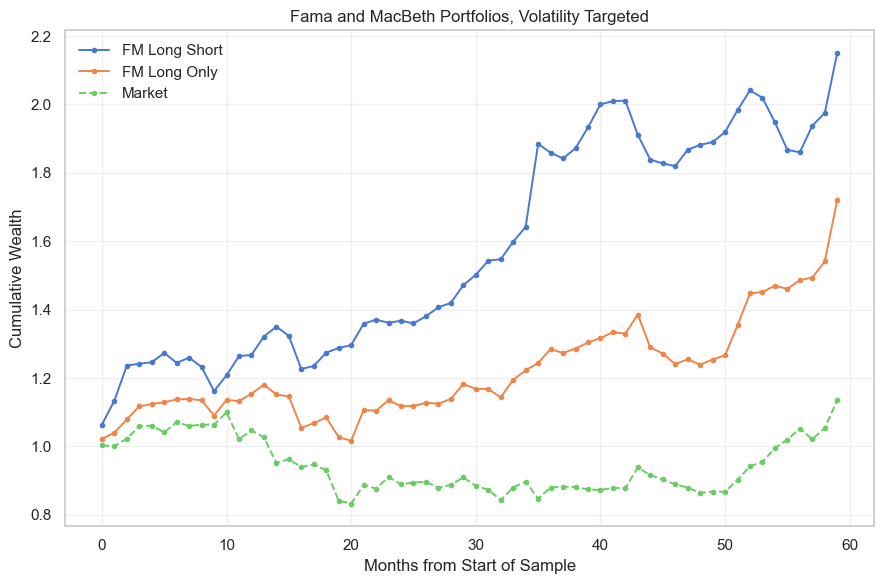

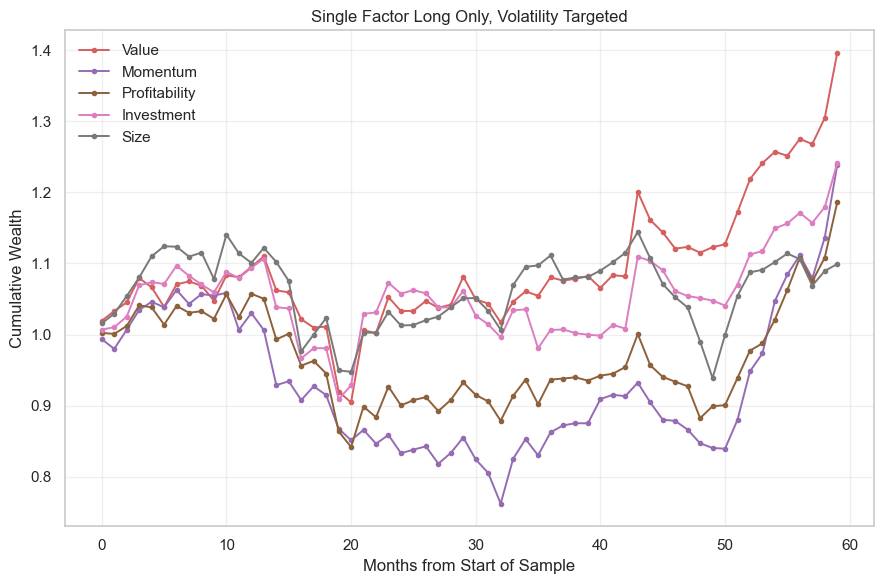

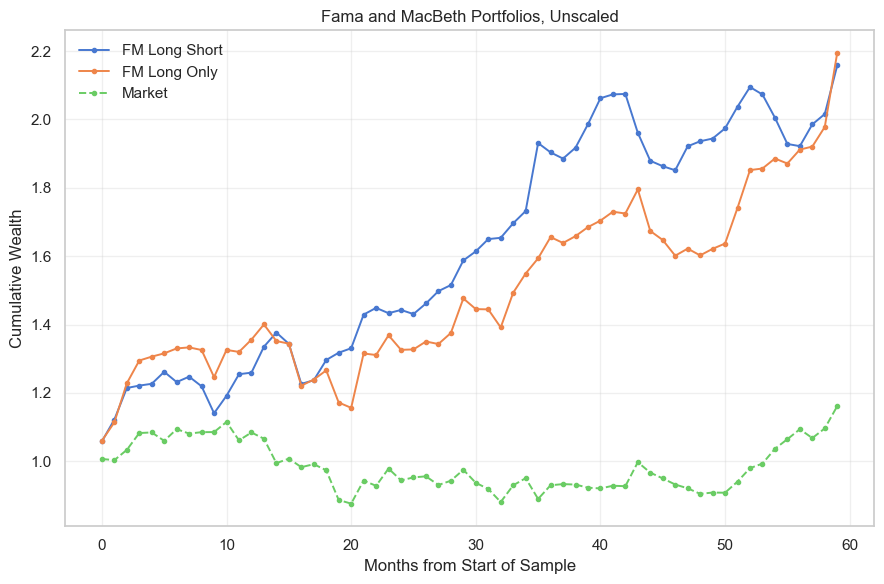

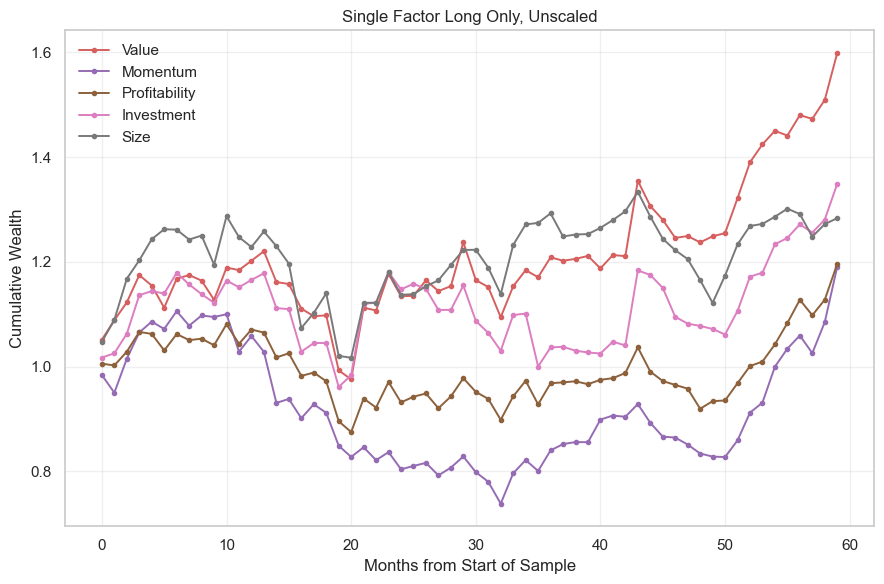

In [3]:
sns.set_theme(style="whitegrid")
palette = sns.color_palette("muted", 8)

fm_ls_color = palette[0]
fm_lo_color = palette[1]
market_color = palette[2]
factor_colors = palette[3:]

marker_style = {'marker': 'o', 'markersize': 3}

# fama and macbeth portfolios, volatility targeted, scaled
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(np.cumprod(1 + fm_ls_scaled), label='FM Long Short', color=fm_ls_color, linewidth=1.4, **marker_style)
ax.plot(np.cumprod(1 + fm_lo_scaled), label='FM Long Only', color=fm_lo_color, linewidth=1.4, **marker_style)
ax.plot(np.cumprod(1 + market_scaled), label='Market', color=market_color, linestyle='--', linewidth=1.4, **marker_style)
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_scaled_fm.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# single factor long only, volatility targeted, scaled
fig, ax = plt.subplots(figsize=(9, 6))
for k, factor in enumerate(factor_order):
	if factor in factor_results:
		ax.plot(np.cumprod(1 + factor_results[factor]['returns_lo_scaled']), label=factor.title(), color=factor_colors[k % len(factor_colors)], linewidth=1.4, **marker_style)
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_scaled_factors.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# fama and macbeth portfolios, unscaled
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(np.cumprod(1 + fm_ls_rets), label='FM Long Short', color=fm_ls_color, linewidth=1.4, **marker_style)
ax.plot(np.cumprod(1 + fm_lo_rets), label='FM Long Only', color=fm_lo_color, linewidth=1.4, **marker_style)
ax.plot(np.cumprod(1 + np.asarray(market_rets)), label='Market', color=market_color, linestyle='--', linewidth=1.4, **marker_style)
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_unscaled_fm.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# single factor long only, unscaled
fig, ax = plt.subplots(figsize=(9, 6))
for k, factor in enumerate(factor_order):
	if factor in factor_results:
		ax.plot(np.cumprod(1 + factor_results[factor]['returns_lo_unscaled']), label=factor.title(), color=factor_colors[k % len(factor_colors)], linewidth=1.4, **marker_style)
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_unscaled_factors.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

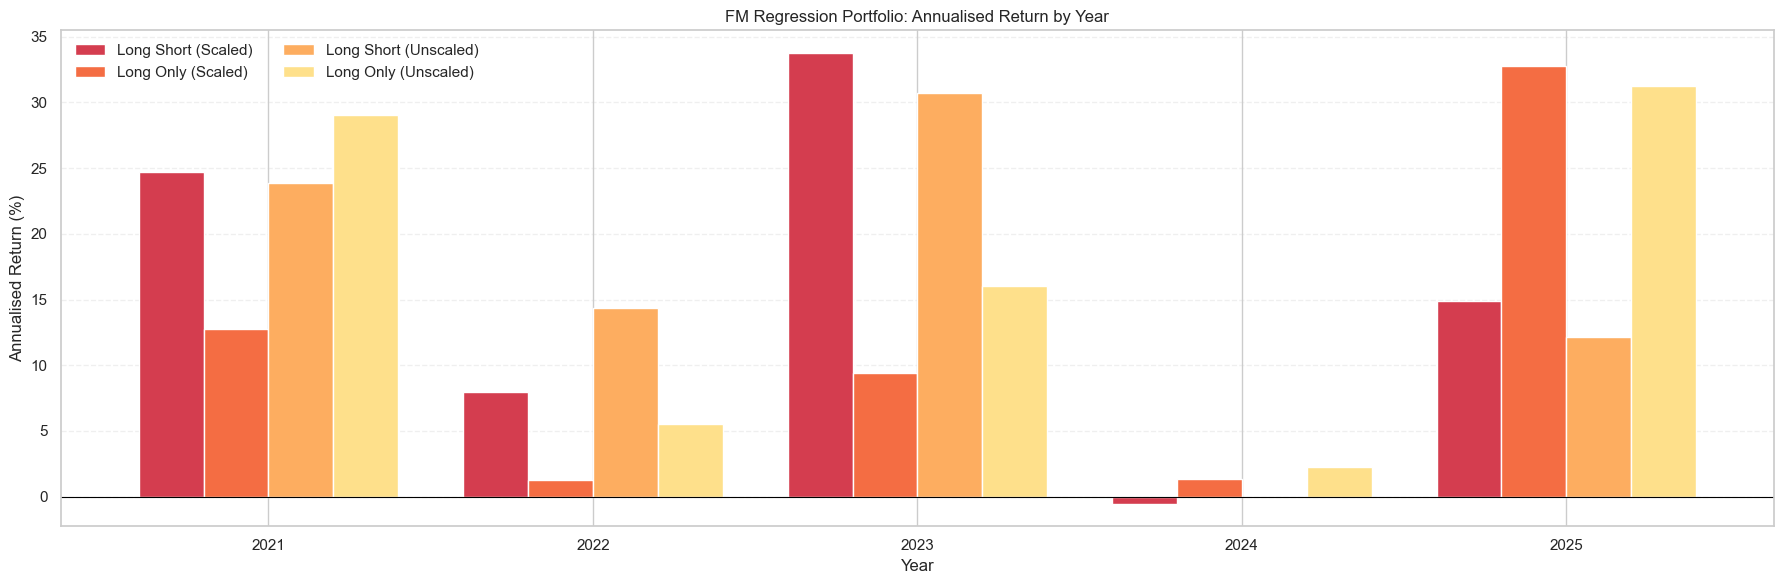

In [4]:
cmap = sns.color_palette("Spectral", as_cmap=True)
palette = [cmap(x) for x in np.linspace(0.1, 0.4, 4)]
sns.set_theme(style="whitegrid")

# separate scaled and unscaled results
fm_scaled = ff_per_year[
	(ff_per_year['strategy'] == 'fm_regression') &
	(ff_per_year['scaling'] == 'scaled')
].copy()

fm_unscaled = ff_per_year[
	(ff_per_year['strategy'] == 'fm_regression') &
	(ff_per_year['scaling'] == 'unscaled')
].copy()

years_ff = sorted(ff_per_year['year'].unique())
x_ff = np.arange(len(years_ff))
width_ff = 0.2

def _ff_val(df, portfolio, year, col):
	sub = df[(df['portfolio'] == portfolio) & (df['year'] == year)]
	return float(sub[col].to_numpy()[0]) if len(sub) > 0 else 0.0

# scaled
ls_scaled = [_ff_val(fm_scaled, 'long_short', y, 'ann_ret') for y in years_ff]
lo_scaled = [_ff_val(fm_scaled, 'long_only', y, 'ann_ret') for y in years_ff]
# unscaled
ls_unscaled = [_ff_val(fm_unscaled, 'long_short', y, 'ann_ret') for y in years_ff]
lo_unscaled = [_ff_val(fm_unscaled, 'long_only', y, 'ann_ret') for y in years_ff]

fig, ax = plt.subplots(figsize=(18, 6))

# plot bars with four different colours
ax.bar(x_ff - 1.5 * width_ff, ls_scaled, width_ff, label='Long Short (Scaled)', color=palette[0])
ax.bar(x_ff - 0.5 * width_ff, lo_scaled, width_ff, label='Long Only (Scaled)', color=palette[1])
ax.bar(x_ff + 0.5 * width_ff, ls_unscaled, width_ff, label='Long Short (Unscaled)', color=palette[2])
ax.bar(x_ff + 1.5 * width_ff, lo_unscaled, width_ff, label='Long Only (Unscaled)', color=palette[3])

# formatting
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_ff)
ax.set_xticklabels(years_ff)
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Return (%)')
ax.set_title('FM Regression Portfolio: Annualised Return by Year')
ax.legend(frameon=False, ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'ff_per_year_bar_scaled_unscaled.png', dpi=300)
plt.show()
plt.close(fig)

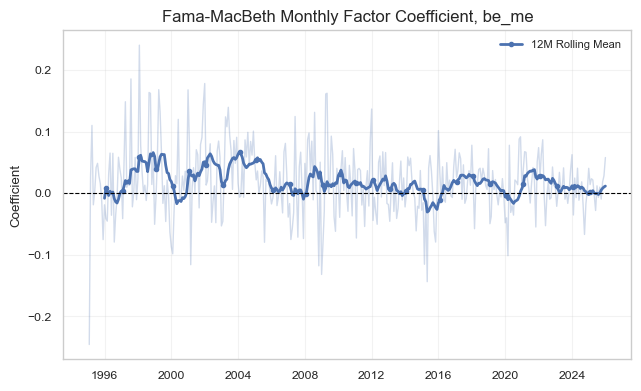

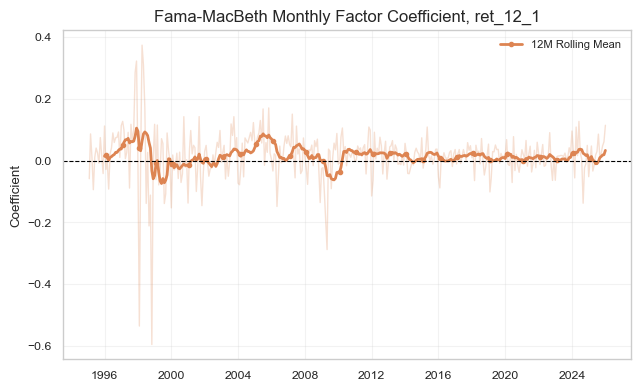

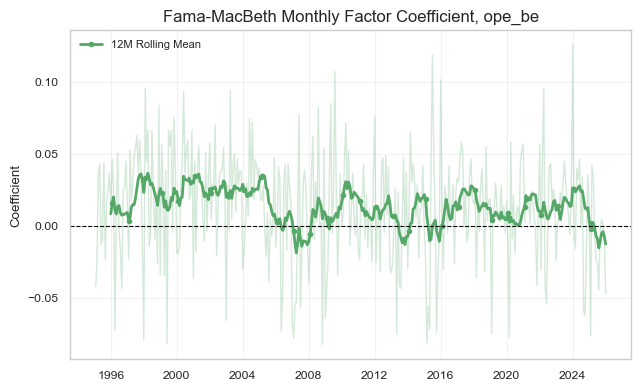

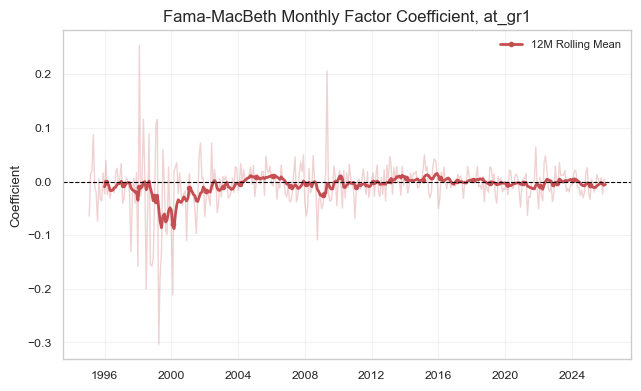

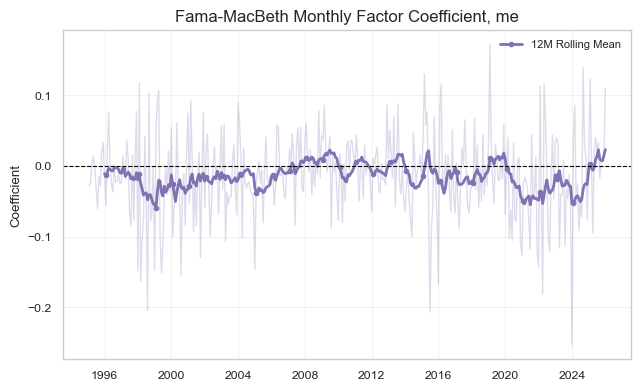

In [5]:
sns.set_theme(style="whitegrid", context="paper")
palette = sns.color_palette("deep")

cols_to_plot = [c for c in fm_betas.columns if c != 'intercept']

for k, col in enumerate(cols_to_plot):
	fig, ax = plt.subplots(figsize=(6.5, 4))

	raw = fm_betas[col].dropna()
	roll = raw.rolling(12).mean()
	colour = palette[k % len(palette)]
	ax.plot(raw.index, raw, color=colour, alpha=0.25, linewidth=1)
	ax.plot(roll.index, roll, color=colour, linewidth=2, marker='o', markersize=3, markevery=12, label='12M Rolling Mean')
	ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
	ax.set_title(f'Fama-MacBeth Monthly Factor Coefficient, {col}', fontsize=12)
	ax.set_xlabel('')
	ax.set_ylabel('Coefficient')
	ax.legend(frameon=False, fontsize=8, loc='best')
	ax.grid(alpha=0.25)

	fig.tight_layout()
	fig.savefig(results_dir / f'ff_fm_beta_stability_{col}.png', dpi=300, bbox_inches='tight')
	plt.show()
	plt.close(fig)

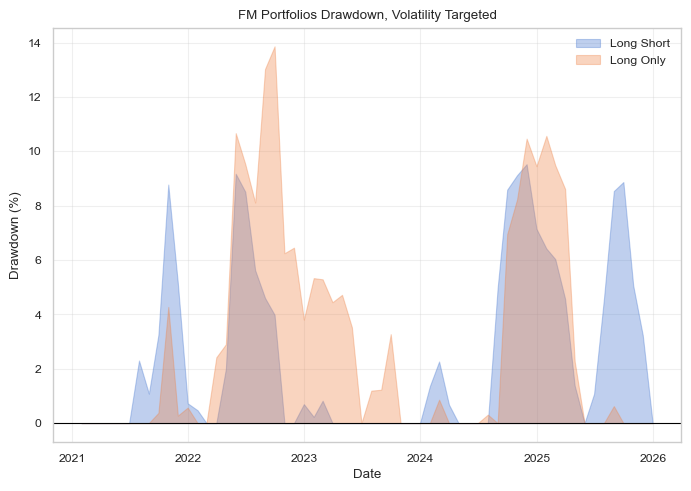

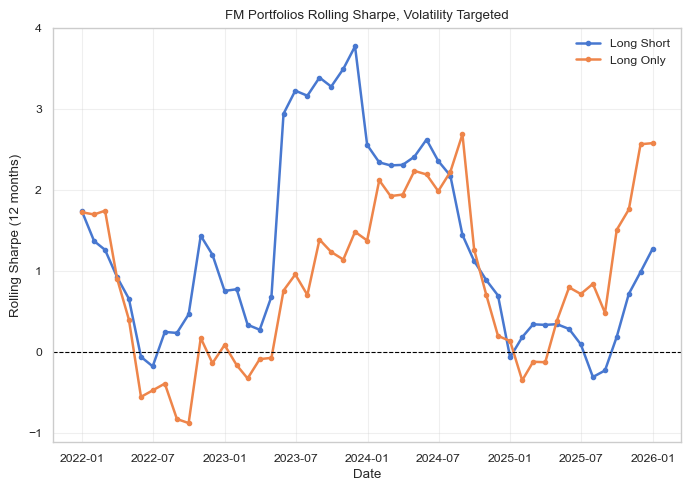

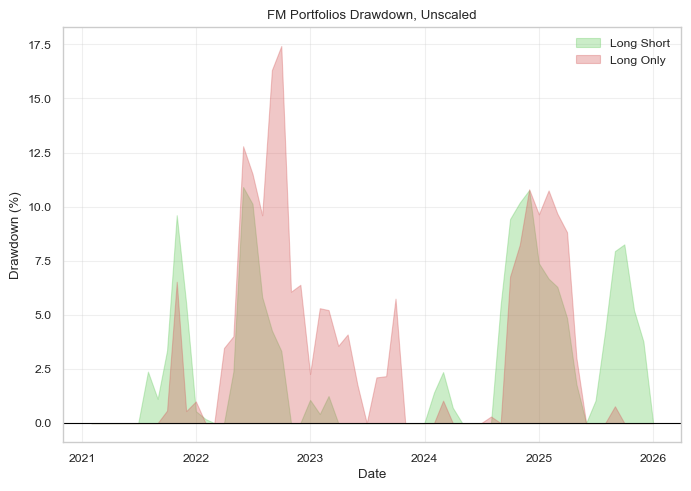

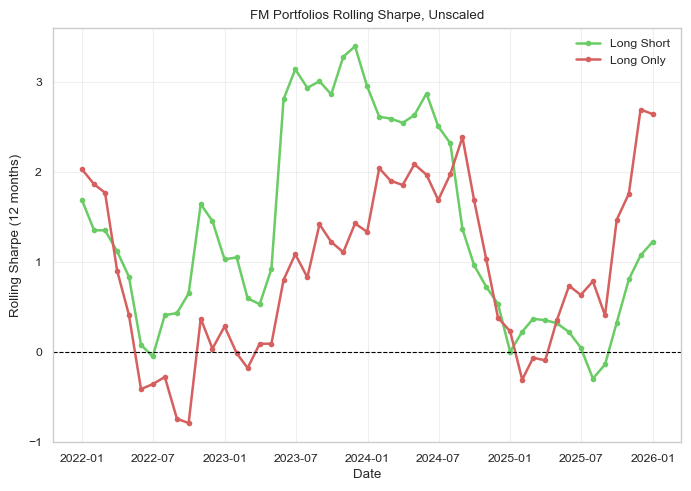

In [6]:
sns.set_theme(style="whitegrid", context="paper")

palette = sns.color_palette("muted", 6)

fm_ls_mo = ff_monthly[(ff_monthly['strategy'] == 'fm_regression') & (ff_monthly['portfolio'] == 'long_short') & (ff_monthly['scaling'] == 'scaled')].sort_values('eom')
fm_lo_mo = ff_monthly[(ff_monthly['strategy'] == 'fm_regression') & (ff_monthly['portfolio'] == 'long_only') & (ff_monthly['scaling'] == 'scaled')].sort_values('eom')

# drawdown, volatility targeted
fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(fm_ls_mo['eom'], fm_ls_mo['drawdown'] * 100, color=palette[0], alpha=0.35, label='Long Short')
ax.fill_between(fm_lo_mo['eom'], fm_lo_mo['drawdown'] * 100, color=palette[1], alpha=0.35, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('FM Portfolios Drawdown, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / 'ff_fm_drawdown_scaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# rolling sharpe, volatility targeted
fig, ax = plt.subplots(figsize=(7, 5))
valid_ls = fm_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = fm_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(fm_ls_mo.loc[valid_ls, 'eom'], fm_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'], color=palette[0], linewidth=1.8, marker='o', markersize=3, label='Long Short')
ax.plot(fm_lo_mo.loc[valid_lo, 'eom'], fm_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'], color=palette[1], linewidth=1.8, marker='o', markersize=3, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('FM Portfolios Rolling Sharpe, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / 'ff_fm_rolling_sharpe_scaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

fm_ls_mo = ff_monthly[(ff_monthly['strategy'] == 'fm_regression') & (ff_monthly['portfolio'] == 'long_short') & (ff_monthly['scaling'] == 'unscaled')].sort_values('eom')
fm_lo_mo = ff_monthly[(ff_monthly['strategy'] == 'fm_regression') & (ff_monthly['portfolio'] == 'long_only') & (ff_monthly['scaling'] == 'unscaled')].sort_values('eom')

# drawdown, unscaled
fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(fm_ls_mo['eom'], fm_ls_mo['drawdown'] * 100, color=palette[2], alpha=0.35, label='Long Short')
ax.fill_between(fm_lo_mo['eom'], fm_lo_mo['drawdown'] * 100, color=palette[3], alpha=0.35, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('FM Portfolios Drawdown, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / 'ff_fm_drawdown_unscaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# rolling sharpe, unscaled
fig, ax = plt.subplots(figsize=(7, 5))
valid_ls = fm_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = fm_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(fm_ls_mo.loc[valid_ls, 'eom'], fm_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'], color=palette[2], linewidth=1.8, marker='o', markersize=3, label='Long Short')
ax.plot(fm_lo_mo.loc[valid_lo, 'eom'], fm_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'], color=palette[3], linewidth=1.8, marker='o', markersize=3, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('FM Portfolios Rolling Sharpe, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / 'ff_fm_rolling_sharpe_unscaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

---
## Gradient Boosting Machines

#### Hyperparameter

In [7]:
# hpt convergence for xgboost and lightgbm from saved optuna trials csv
with open(tree_dir / 'xgb_best_params.json') as fh:
	xgb_info = json.load(fh)
with open(tree_dir / 'lgb_best_params.json') as fh:
	lgb_info = json.load(fh)

print(f'xgboost best val ls sharpe: {xgb_info["best_value"]:.4f}')
print(f'xgboost best params: {xgb_info["best_params"]}')
print()
print(f'lightgbm best val ls sharpe: {lgb_info["best_value"]:.4f}')
print(f'lightgbm best params: {lgb_info["best_params"]}')


xgboost best val ls sharpe: 2.0636
xgboost best params: {'n_estimators': 349, 'max_depth': 4, 'learning_rate': 0.18709852869202037, 'subsample': 0.9433559459220114, 'colsample_bytree': 0.43002964488683815, 'min_child_weight': 3, 'reg_alpha': 0.01700174641931628, 'reg_lambda': 0.0060211893083009825}

lightgbm best val ls sharpe: 2.1303
lightgbm best params: {'n_estimators': 192, 'max_depth': 7, 'learning_rate': 0.06838973936800209, 'num_leaves': 64, 'subsample': 0.6804202771550869, 'colsample_bytree': 0.4021331026942422, 'min_child_samples': 29, 'reg_alpha': 0.0014437399425391306, 'reg_lambda': 0.0037515604876097487}


### XGBoost and LightGBM

In [8]:
xgb_ls_df = pd.read_csv(tree_dir / 'xgb_returns_long_short.csv')
xgb_lo_df = pd.read_csv(tree_dir / 'xgb_returns_long_only.csv')
lgb_ls_df = pd.read_csv(tree_dir / 'lgb_returns_long_short.csv')
lgb_lo_df = pd.read_csv(tree_dir / 'lgb_returns_long_only.csv')
xgb_ls_df['eom'] = pd.to_datetime(xgb_ls_df['eom'])
xgb_lo_df['eom'] = pd.to_datetime(xgb_lo_df['eom'])
lgb_ls_df['eom'] = pd.to_datetime(lgb_ls_df['eom'])
lgb_lo_df['eom'] = pd.to_datetime(lgb_lo_df['eom'])

xgb_eval = {
	'returns_ls_scaled': xgb_ls_df['return_scaled'].to_numpy(),
	'returns_ls_unscaled': xgb_ls_df['return_unscaled'].to_numpy(),
	'returns_lo_scaled': xgb_lo_df['return_scaled'].to_numpy(),
	'returns_lo_unscaled': xgb_lo_df['return_unscaled'].to_numpy(),
	'leverage_ls': xgb_ls_df['leverage'].to_numpy(),
	'leverage_lo': xgb_lo_df['leverage'].to_numpy(),
}
lgb_eval = {
	'returns_ls_scaled': lgb_ls_df['return_scaled'].to_numpy(),
	'returns_ls_unscaled': lgb_ls_df['return_unscaled'].to_numpy(),
	'returns_lo_scaled': lgb_lo_df['return_scaled'].to_numpy(),
	'returns_lo_unscaled': lgb_lo_df['return_unscaled'].to_numpy(),
	'leverage_ls': lgb_ls_df['leverage'].to_numpy(),
	'leverage_lo': lgb_lo_df['leverage'].to_numpy(),
}

xgb_imp = pd.read_csv(tree_dir / 'xgb_feature_importance.csv').sort_values('importance', ascending=False)
lgb_imp = pd.read_csv(tree_dir / 'lgb_feature_importance.csv').sort_values('importance', ascending=False)

tree_summary = pd.read_csv(tree_dir / 'tree_summary.csv')

results_dir = Path('plots') / tree_dir.name
results_dir.mkdir(parents=True, exist_ok=True)

print(f'xgb periods: {len(xgb_ls_df)}, lgb periods: {len(lgb_ls_df)}')
print()
print('tree benchmark headline summary')
print(tree_summary.to_string(index=False))


xgb periods: 10, lgb periods: 10

tree benchmark headline summary
   model  portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  cagr  cum_return  max_dd  n_obs
 xgboost long_short unscaled   0.0944  1.2194 0.4175    18.02    14.78 17.78      126.70    7.55     10
 xgboost long_short   scaled   0.0944  1.3986 0.4447    14.01    10.02 14.01       92.59    2.86     10
 xgboost  long_only unscaled   0.0944  1.1027 0.4010    15.29    13.87 14.97      100.86    7.88     10
 xgboost  long_only   scaled   0.0944  1.1010 0.4008    13.46    12.23 13.21       85.95    4.06     10
lightgbm long_short unscaled   0.1056  1.4133 0.4471    19.03    13.47 19.07      139.36    3.79     10
lightgbm long_short   scaled   0.1056  1.4448 0.4521    16.03    11.09 16.07      110.69    1.45     10
lightgbm  long_only unscaled   0.1056  1.1146 0.4026    15.18    13.62 14.88      100.05    7.85     10
lightgbm  long_only   scaled   0.1056  1.1087 0.4018    13.52    12.19 13.27       86.48    4.17     1

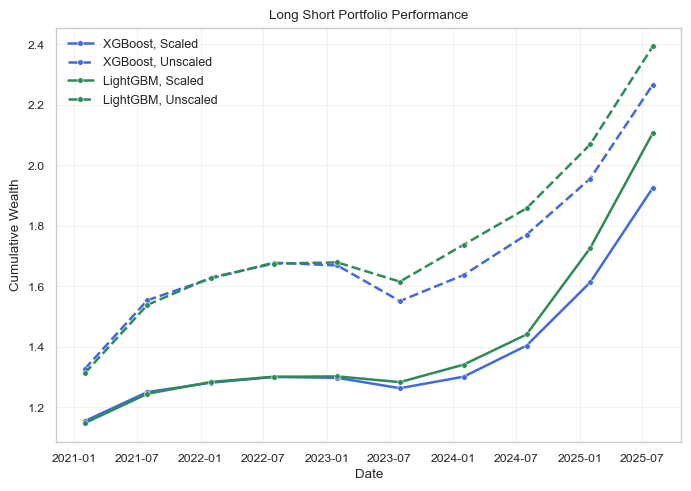

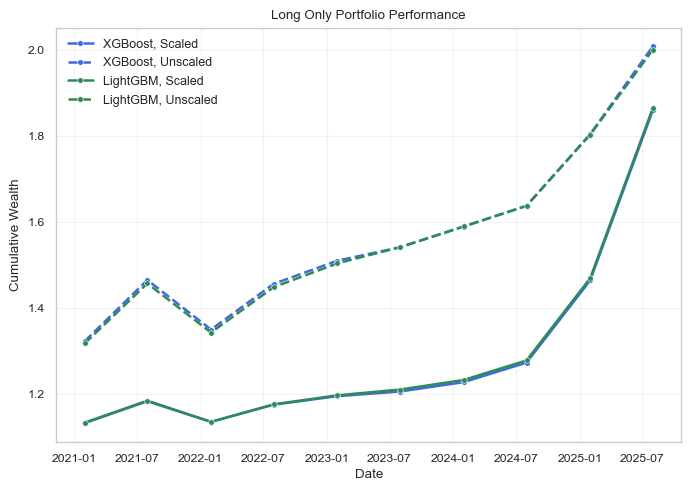

In [9]:
xgb_color = 'royalblue'
lgb_color = 'seagreen'

marker_style = {'marker': 'o', 'markersize': 4, 'markeredgecolor': 'white', 'markeredgewidth': 0.4}

# long short
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xgb_ls_df['eom'], np.cumprod(1 + xgb_eval['returns_ls_scaled']), label='XGBoost, Scaled', color=xgb_color, linewidth=1.8, **marker_style)
ax.plot(xgb_ls_df['eom'], np.cumprod(1 + xgb_eval['returns_ls_unscaled']), label='XGBoost, Unscaled', color=xgb_color, linestyle='--', linewidth=1.8, **marker_style)
ax.plot(lgb_ls_df['eom'], np.cumprod(1 + lgb_eval['returns_ls_scaled']), label='LightGBM, Scaled', color=lgb_color, linewidth=1.8, **marker_style)
ax.plot(lgb_ls_df['eom'], np.cumprod(1 + lgb_eval['returns_ls_unscaled']), label='LightGBM, Unscaled', color=lgb_color, linestyle='--', linewidth=1.8, **marker_style)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short Portfolio Performance')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(results_dir / 'tree_cumulative_long_short.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# long only
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xgb_lo_df['eom'], np.cumprod(1 + xgb_eval['returns_lo_scaled']), label='XGBoost, Scaled', color=xgb_color, linewidth=1.8, **marker_style)
ax.plot(xgb_lo_df['eom'], np.cumprod(1 + xgb_eval['returns_lo_unscaled']), label='XGBoost, Unscaled', color=xgb_color, linestyle='--', linewidth=1.8, **marker_style)
ax.plot(lgb_lo_df['eom'], np.cumprod(1 + lgb_eval['returns_lo_scaled']), label='LightGBM, Scaled', color=lgb_color, linewidth=1.8, **marker_style)
ax.plot(lgb_lo_df['eom'], np.cumprod(1 + lgb_eval['returns_lo_unscaled']), label='LightGBM, Unscaled', color=lgb_color, linestyle='--', linewidth=1.8, **marker_style)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only Portfolio Performance')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(results_dir / 'tree_cumulative_long_only.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


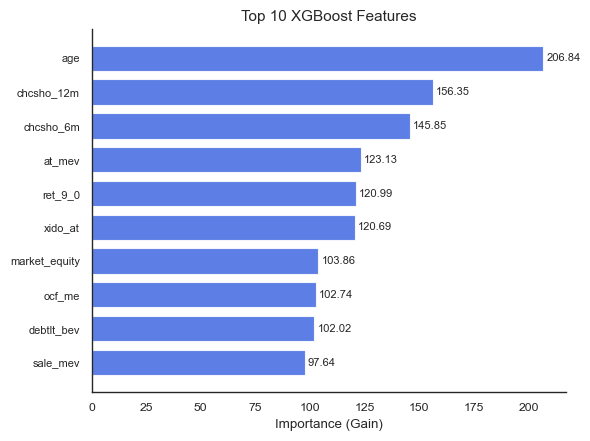

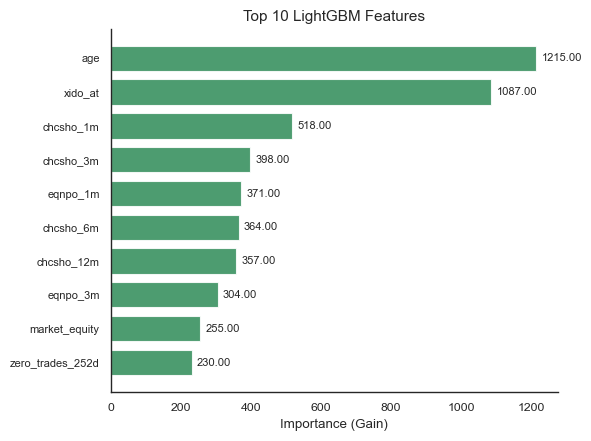

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="paper")

xgb_color = 'royalblue'
lgb_color = 'seagreen'
top_n = 10

top_xgb = xgb_imp.head(top_n).sort_values('importance')
top_lgb = lgb_imp.head(top_n).sort_values('importance')

# xgboost
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(top_xgb['feature'], top_xgb['importance'], color=xgb_color, alpha=0.85, height=0.75)
for i, v in enumerate(top_xgb['importance']):
	ax.text(v + 1.4, i, f'{v:.2f}', va='center', fontsize=8, ha='left')
ax.set_title('Top 10 XGBoost Features', fontsize=11)
ax.set_xlabel('Importance (Gain)')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
ax.grid(False)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(results_dir / 'tree_feature_importance_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# lightgbm
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(top_lgb['feature'], top_lgb['importance'], color=lgb_color, alpha=0.85, height=0.75)
for i, v in enumerate(top_lgb['importance']):
	ax.text(v + 15, i, f'{v:.2f}', va='center', fontsize=8, ha='left')
ax.set_title('Top 10 LightGBM Features', fontsize=11)
ax.set_xlabel('Importance (Gain)')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
ax.grid(False)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(results_dir / 'tree_feature_importance_lightgbm.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

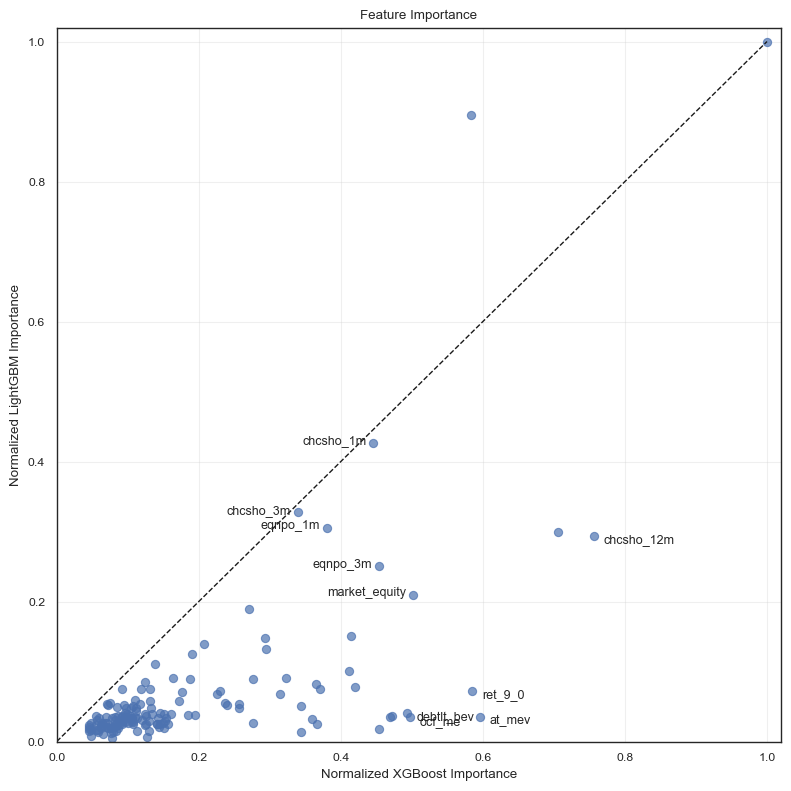

In [11]:
# merge feature importances
cmp = (
	xgb_imp[['feature', 'importance']].rename(columns={'importance': 'XGBoost'})
	.merge(lgb_imp[['feature', 'importance']]
		.rename(columns={'importance': 'LightGBM'}), on='feature', how='outer'
	).fillna(0).set_index('feature')
)

# normalize importances
cmp['XGB'] = cmp['XGBoost'] / cmp['XGBoost'].max()
cmp['LGB'] = cmp['LightGBM'] / cmp['LightGBM'].max()

# distance from diagonal
cmp['diag_dist'] = np.abs(cmp['XGB'] - cmp['LGB'])

# label points
outlier_points = cmp.nlargest(5, 'diag_dist')
box_points = cmp[cmp['XGB'].between(0.2, 0.6) & cmp['LGB'].between(0.2, 0.6)]
label_points = pd.concat([outlier_points, box_points])
label_points = label_points.loc[~label_points.index.duplicated()]

# scatter plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(cmp['XGB'], cmp['LGB'], s=35, alpha=0.7)
ax.plot([0, 1], [0, 1], 'k--', lw=1)

# label the outliers
for feature, row in outlier_points.iterrows():
	ax.annotate(
		feature, (row['XGB'], row['LGB']),
		xytext=(7, -3), textcoords='offset points',
		fontsize=9, ha='left', va='center'
	)

# label the points inside the box
for feature, row in box_points.iterrows():
	ax.annotate(
		feature, (row['XGB'], row['LGB']),
		xytext=(-5, -3), textcoords='offset points',
		fontsize=9, ha='right', va='bottom'
	)

ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)

ax.set_xlabel('Normalized XGBoost Importance')
ax.set_ylabel('Normalized LightGBM Importance')
ax.set_title('Feature Importance')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'feature_importance_scatter.png', dpi=300)

plt.show()
plt.close(fig)

#### Prediction Accuracy

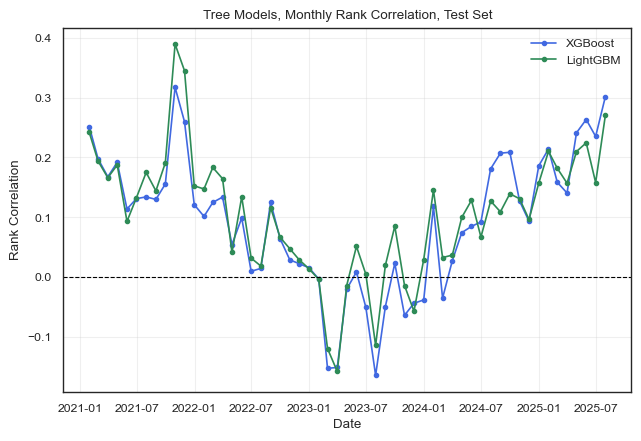

In [12]:
# read the per firm month test set predictions for each tree model.
# each read is defensive, since the exact output of tree_benchmark has
# not been directly verified against the notebook in this session.
def load_tree_predictions(path):
	try:
		df = pd.read_csv(path)
	except FileNotFoundError:
		print(f'{path.name} not found, skipping this diagnostic')
		return None
	df['eom'] = pd.to_datetime(df['eom'])
	return df


def monthly_rank_corr(df):
	rows = []
	for eom, group in df.groupby('eom'):
		valid = group['prediction'].notna() & group['realised_return'].notna()
		if valid.sum() < 10:
			continue
		c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method='spearman')
		rows.append({'eom': eom, 'rank_corr': c})
	return pd.DataFrame(rows).sort_values('eom')


xgb_test_pred = load_tree_predictions(tree_dir / 'xgb_test_predictions.csv')
lgb_test_pred = load_tree_predictions(tree_dir / 'lgb_test_predictions.csv')

if xgb_test_pred is not None and lgb_test_pred is not None:
	xgb_monthly_corr = monthly_rank_corr(xgb_test_pred)
	lgb_monthly_corr = monthly_rank_corr(lgb_test_pred)

	# monthly rank correlation
	fig, ax = plt.subplots(figsize=(6.5, 4.5))
	ax.plot(xgb_monthly_corr['eom'].to_numpy(), xgb_monthly_corr['rank_corr'].to_numpy(), color=xgb_color, marker='o', markersize=3, label='XGBoost')
	ax.plot(lgb_monthly_corr['eom'].to_numpy(), lgb_monthly_corr['rank_corr'].to_numpy(), color=lgb_color, marker='o', markersize=3, label='LightGBM')
	ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
	ax.set_xlabel('Date')
	ax.set_ylabel('Rank Correlation')
	ax.set_title('Tree Models, Monthly Rank Correlation, Test Set')
	ax.legend(frameon=False)
	ax.grid(alpha=0.3)
	fig.tight_layout()
	fig.savefig(results_dir / 'tree_prediction_monthly_corr.png')
	plt.show()
	plt.close(fig)


---
## Multi-Layer Perceptron

In [13]:
mlp_color1 = 'C0'

mlp_ls_df = pd.read_csv(mlp_dir / 'mlp_returns_long_short.csv')
mlp_lo_df = pd.read_csv(mlp_dir / 'mlp_returns_long_only.csv')
mlp_ls_df['eom'] = pd.to_datetime(mlp_ls_df['eom'])
mlp_lo_df['eom'] = pd.to_datetime(mlp_lo_df['eom'])

mlp_eval = {
	'returns_ls_scaled': mlp_ls_df['return_scaled'].to_numpy(),
	'returns_ls_unscaled': mlp_ls_df['return_unscaled'].to_numpy(),
	'returns_lo_scaled': mlp_lo_df['return_scaled'].to_numpy(),
	'returns_lo_unscaled': mlp_lo_df['return_unscaled'].to_numpy(),
	'leverage_ls': mlp_ls_df['leverage'].to_numpy(),
	'leverage_lo': mlp_lo_df['leverage'].to_numpy(),
}

mlp_per_month = pd.read_csv(mlp_dir / 'mlp_per_month_metrics.csv')
mlp_per_month['eom'] = pd.to_datetime(mlp_per_month['eom'])

with open(mlp_dir / 'mlp_train_log.json') as fh:
	mlp_train_log = json.load(fh)

mlp_summary = pd.read_csv(mlp_dir / 'mlp_summary.csv')

results_dir_mlp = Path('plots') / mlp_dir.name
results_dir_mlp.mkdir(parents=True, exist_ok=True)

print(f'mlp periods: {len(mlp_ls_df)}, monthly rows: {len(mlp_per_month)}')
print(f'train epochs: {len(mlp_train_log["train_losses"])}')
print()
print('mlp benchmark headline summary')
print(mlp_summary.to_string(index=False))


mlp periods: 10, monthly rows: 220
train epochs: 2

mlp benchmark headline summary
model  portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  cagr  cum_return  max_dd  n_obs
  mlp long_short unscaled   0.1485  2.2444 0.5932    15.53     6.92 15.89      109.08    1.24     10
  mlp long_short   scaled   0.1485  1.4709 0.4563    29.90    20.33 30.26      274.95    3.71     10
  mlp  long_only unscaled   0.1485  1.1299 0.4048    14.45    12.79 14.19       94.15    7.98     10
  mlp  long_only   scaled   0.1485  1.1236 0.4039    13.69    12.18 13.45       87.93    5.24     10


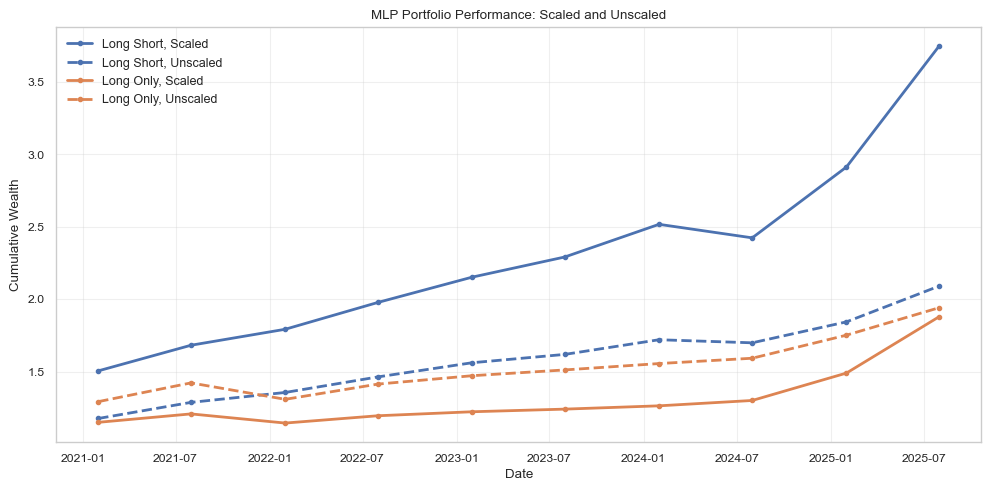

In [14]:
sns.set_theme(style="whitegrid", context="paper")

palette = sns.color_palette("deep", 2)
ls_color = palette[0]
lo_color = palette[1]

fig, ax = plt.subplots(figsize=(10, 5))

ls_scaled = np.cumprod(1 + mlp_eval['returns_ls_scaled'])
ls_unscaled = np.cumprod(1 + mlp_eval['returns_ls_unscaled'])
lo_scaled = np.cumprod(1 + mlp_eval['returns_lo_scaled'])
lo_unscaled = np.cumprod(1 + mlp_eval['returns_lo_unscaled'])

ax.plot(mlp_ls_df['eom'], ls_scaled, label='Long Short, Scaled', color=ls_color, linewidth=2, marker='o', markersize=3)
ax.plot(mlp_ls_df['eom'], ls_unscaled, label='Long Short, Unscaled', color=ls_color, linestyle='--', linewidth=2, marker='o', markersize=3)
ax.plot(mlp_lo_df['eom'], lo_scaled, label='Long Only, Scaled', color=lo_color, linewidth=2, marker='o', markersize=3)
ax.plot(mlp_lo_df['eom'], lo_unscaled, label='Long Only, Unscaled', color=lo_color, linestyle='--', linewidth=2, marker='o', markersize=3)

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('MLP Portfolio Performance: Scaled and Unscaled')
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_cumulative_combined.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


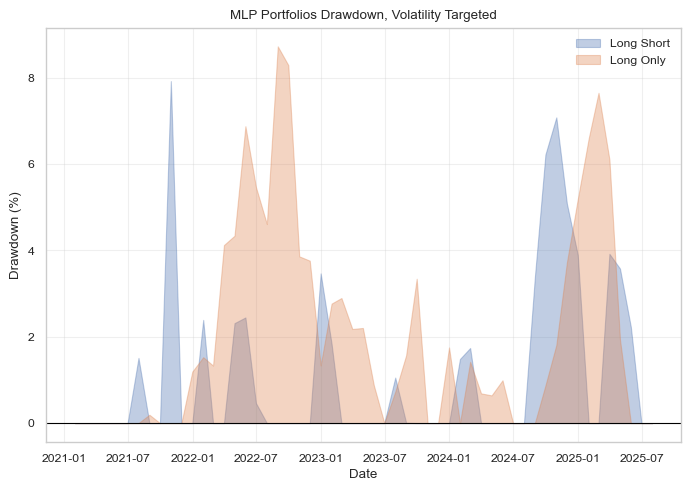

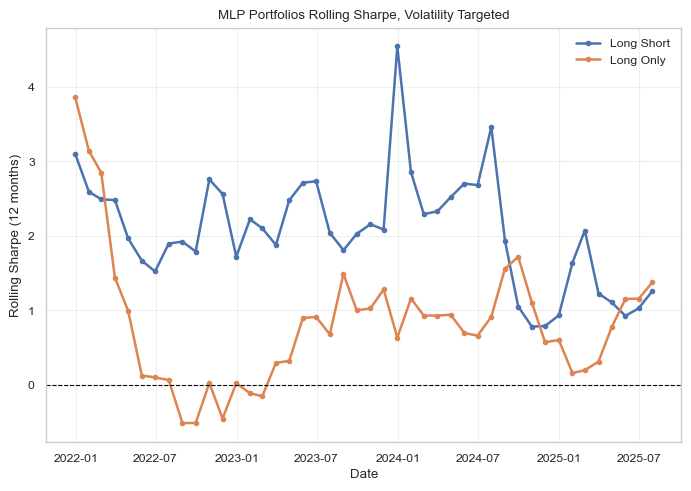

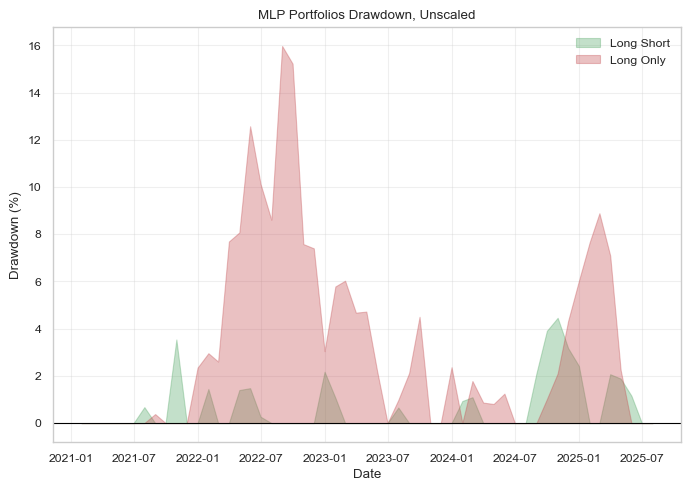

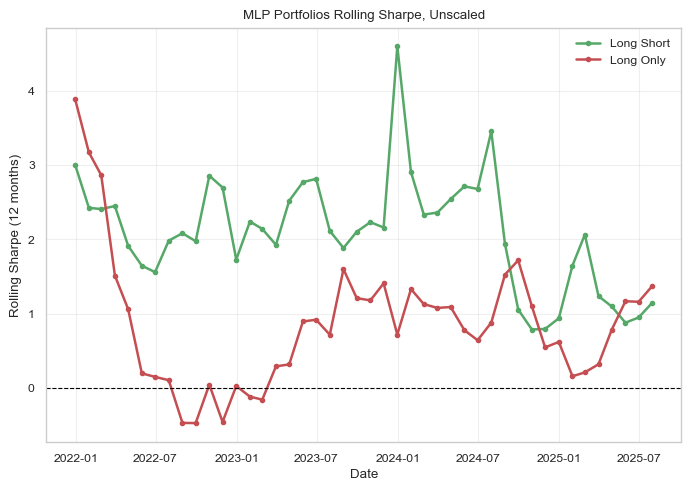

In [15]:
sns.set_theme(style="whitegrid", context="paper")

palette = sns.color_palette("deep", 6)

mlp_ls_mo = mlp_per_month[(mlp_per_month['portfolio'] == 'long_short') & (mlp_per_month['scaling'] == 'scaled')].sort_values('eom')
mlp_lo_mo = mlp_per_month[(mlp_per_month['portfolio'] == 'long_only') & (mlp_per_month['scaling'] == 'scaled')].sort_values('eom')

# drawdown, volatility targeted
fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(mlp_ls_mo['eom'], mlp_ls_mo['drawdown'] * 100, color=palette[0], alpha=0.35, label='Long Short')
ax.fill_between(mlp_lo_mo['eom'], mlp_lo_mo['drawdown'] * 100, color=palette[1], alpha=0.35, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('MLP Portfolios Drawdown, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_drawdown_scaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# rolling sharpe, volatility targeted
fig, ax = plt.subplots(figsize=(7, 5))
valid_ls = mlp_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = mlp_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(mlp_ls_mo.loc[valid_ls, 'eom'], mlp_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'], color=palette[0], linewidth=1.8, marker='o', markersize=3, label='Long Short')
ax.plot(mlp_lo_mo.loc[valid_lo, 'eom'], mlp_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'], color=palette[1], linewidth=1.8, marker='o', markersize=3, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('MLP Portfolios Rolling Sharpe, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_rolling_sharpe_scaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

mlp_ls_mo = mlp_per_month[(mlp_per_month['portfolio'] == 'long_short') & (mlp_per_month['scaling'] == 'unscaled')].sort_values('eom')
mlp_lo_mo = mlp_per_month[(mlp_per_month['portfolio'] == 'long_only') & (mlp_per_month['scaling'] == 'unscaled')].sort_values('eom')

# drawdown, unscaled
fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(mlp_ls_mo['eom'], mlp_ls_mo['drawdown'] * 100, color=palette[2], alpha=0.35, label='Long Short')
ax.fill_between(mlp_lo_mo['eom'], mlp_lo_mo['drawdown'] * 100, color=palette[3], alpha=0.35, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('MLP Portfolios Drawdown, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_drawdown_unscaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# rolling sharpe, unscaled
fig, ax = plt.subplots(figsize=(7, 5))
valid_ls = mlp_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = mlp_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(mlp_ls_mo.loc[valid_ls, 'eom'], mlp_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'], color=palette[2], linewidth=1.8, marker='o', markersize=3, label='Long Short')
ax.plot(mlp_lo_mo.loc[valid_lo, 'eom'], mlp_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'], color=palette[3], linewidth=1.8, marker='o', markersize=3, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('MLP Portfolios Rolling Sharpe, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_rolling_sharpe_unscaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

#### Prediction Accuracy

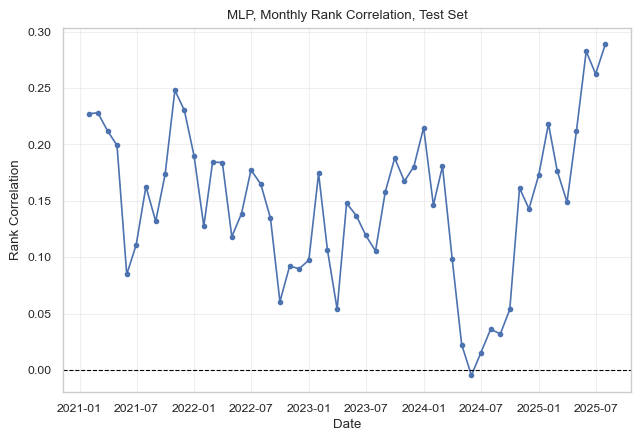

In [16]:
# defensive read of the per firm month test set predictions for the mlp
try:
	mlp_test_pred = pd.read_csv(mlp_dir / 'mlp_test_predictions.csv')
	mlp_test_pred['eom'] = pd.to_datetime(mlp_test_pred['eom'])
except FileNotFoundError:
	mlp_test_pred = None
	print('mlp_test_predictions.csv not found, skipping this diagnostic')

if mlp_test_pred is not None:
	rows = []
	for eom, group in mlp_test_pred.groupby('eom'):
		valid = group['prediction'].notna() & group['realised_return'].notna()
		if valid.sum() < 10:
			continue
		c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method='spearman')
		rows.append({'eom': eom, 'rank_corr': c})
	mlp_monthly_corr = pd.DataFrame(rows).sort_values('eom')

	# monthly rank correlation
	fig, ax = plt.subplots(figsize=(6.5, 4.5))
	ax.plot(mlp_monthly_corr['eom'].to_numpy(), mlp_monthly_corr['rank_corr'].to_numpy(), color=mlp_color1, marker='o', markersize=3)
	ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
	ax.set_xlabel('Date')
	ax.set_ylabel('Rank Correlation')
	ax.set_title('MLP, Monthly Rank Correlation, Test Set')
	ax.grid(alpha=0.3)
	fig.tight_layout()
	fig.savefig(results_dir_mlp / 'mlp_prediction_monthly_corr.png')
	plt.show()
	plt.close(fig)


---
## FT-Transformer

#### Hyperparameter

In [17]:
ft_dir = Path('results/benchmark/ft_transformer_benchmark')
ft_plots_dir = Path('plots') / ft_dir.name
ft_plots_dir.mkdir(parents=True, exist_ok=True)
ft_color = 'royalblue'

with open(ft_dir / 'ft_best_params.json') as fh:
	ft_best_params_info = json.load(fh)

ua = ft_best_params_info['best_trial_user_attrs']
print('ft-transformer, hyperparameter search summary')
print(f'best trial number, {ft_best_params_info["best_trial_number"]}')
print(f'best val long short sharpe, {ft_best_params_info["best_val_long_short_sharpe"]:.4f}')
print(f'val long only sharpe, {ua.get("val_sharpe_long_only", float("nan")):.4f}')
print(f'best epoch, {ua.get("best_epoch")}, epochs run, {ua.get("n_epochs_run")}')
print(f'd_model, {ua.get("d_model")}, d_ff, {ua.get("d_ff")}, param count, {ua.get("param_count")}')
print(f'best params, {ft_best_params_info["best_params"]}')
print(f'trials completed, {ft_best_params_info["n_trials_completed"]}')


ft-transformer, hyperparameter search summary
best trial number, 14
best val long short sharpe, 2.9072
val long only sharpe, 0.5895
best epoch, 3, epochs run, 12
d_model, 32, d_ff, 128, param count, 70305
best params, {'n_heads': 4, 'd_model_per_head': 8, 'd_ff_ratio': 4, 'n_layers': 3, 'dropout': 0.17625915357156158, 'batch_size': 512, 'learning_rate': 0.0002627111859266744, 'weight_decay': 0.0002908992041150531}
trials completed, 30


### FT-Transformer

In [18]:
ft_ls_df = pd.read_csv(ft_dir / 'ft_returns_long_short.csv')
ft_lo_df = pd.read_csv(ft_dir / 'ft_returns_long_only.csv')
ft_ls_df['eom'] = pd.to_datetime(ft_ls_df['eom'])
ft_lo_df['eom'] = pd.to_datetime(ft_lo_df['eom'])

with open(ft_dir / 'ft_train_log.json') as fh:
	ft_train_log = json.load(fh)

ft_summary = pd.read_csv(ft_dir / 'ft_summary.csv')

rebalance_freq_ft = 6

print(f'ft periods, {len(ft_ls_df)}')
print(f'train epochs, {len(ft_train_log["train_losses"])}')
print('ft-transformer benchmark headline summary')
print(ft_summary.to_string(index=False))


ft periods, 10
train epochs, 9
ft-transformer benchmark headline summary
 portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  cagr  max_dd  n_obs
long_short unscaled   0.1206  1.9330 0.5356    14.16     7.33 14.42    0.39     10
long_short   scaled   0.1206  1.2989 0.4294    26.74    20.59 26.83    0.85     10
 long_only unscaled   0.1206  0.9353 0.3791    12.73    13.62 12.35    7.51     10
 long_only   scaled   0.1206  0.9990 0.3872     8.09     8.10  7.97    4.48     10


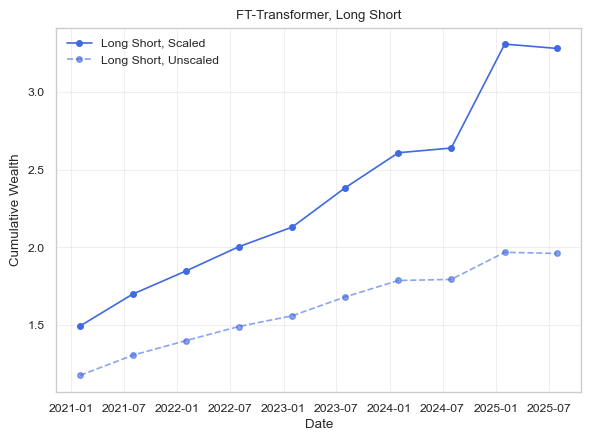

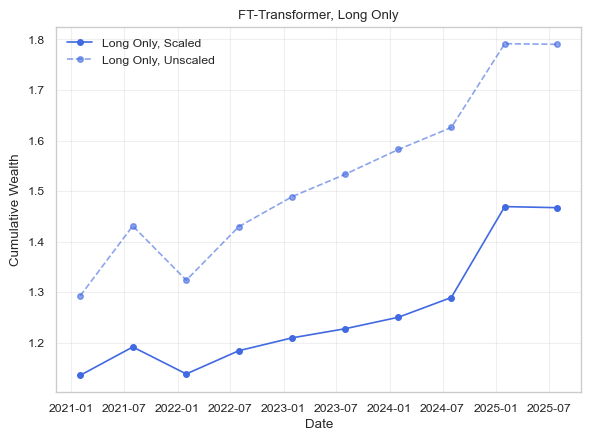

In [19]:
# ft-transformer, long short
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(ft_ls_df['eom'], np.cumprod(1 + ft_ls_df['return_scaled'].to_numpy()), label='Long Short, Scaled', color=ft_color, marker='o', markersize=4)
ax.plot(ft_ls_df['eom'], np.cumprod(1 + ft_ls_df['return_unscaled'].to_numpy()), label='Long Short, Unscaled', color=ft_color, linestyle='--', alpha=0.6, marker='o', markersize=4)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('FT-Transformer, Long Short')
ax.legend(frameon=False, loc='upper left')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_cumulative_wealth_long_short.png')
plt.show()
plt.close(fig)

# ft-transformer, long only
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(ft_lo_df['eom'], np.cumprod(1 + ft_lo_df['return_scaled'].to_numpy()), label='Long Only, Scaled', color=ft_color, marker='o', markersize=4)
ax.plot(ft_lo_df['eom'], np.cumprod(1 + ft_lo_df['return_unscaled'].to_numpy()), label='Long Only, Unscaled', color=ft_color, linestyle='--', alpha=0.6, marker='o', markersize=4)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('FT-Transformer, Long Only')
ax.legend(frameon=False, loc='upper left')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_cumulative_wealth_long_only.png')
plt.show()
plt.close(fig)


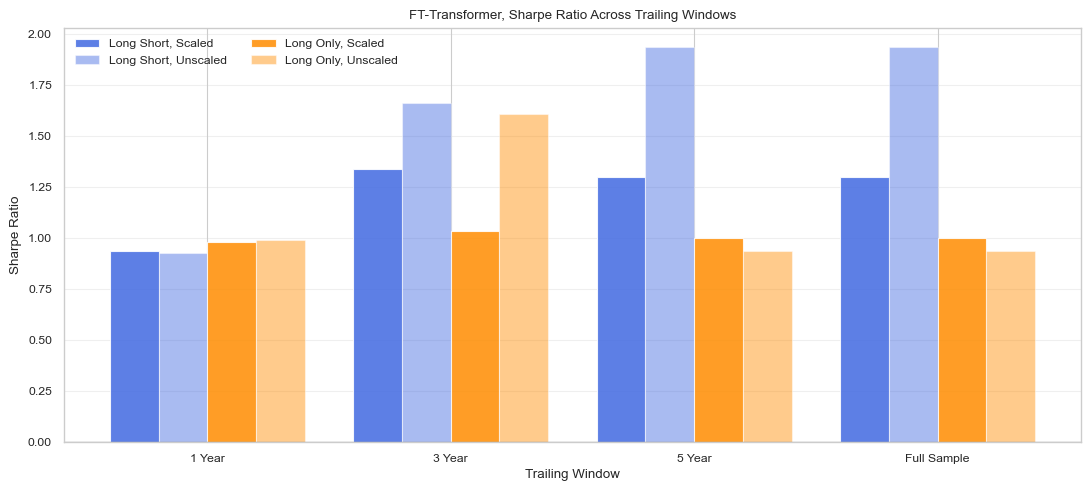

In [20]:
def ft_trailing_sharpe(returns, periods_per_year, n_periods):
	window = returns[-n_periods:] if len(returns) >= n_periods else returns
	if len(window) < 2:
		return float('nan')
	ann_ret = float(np.mean(window) * periods_per_year)
	ann_vol = float(np.std(window, ddof=1) * np.sqrt(periods_per_year))
	return ann_ret / ann_vol if ann_vol > 0 else float('nan')


ls_scaled_returns = ft_ls_df['return_scaled'].to_numpy()
ls_unscaled_returns = ft_ls_df['return_unscaled'].to_numpy()
lo_scaled_returns = ft_lo_df['return_scaled'].to_numpy()
lo_unscaled_returns = ft_lo_df['return_unscaled'].to_numpy()
periods_per_year_ft = 12.0 / rebalance_freq_ft
window_months_ft = {'sharpe_1y': 12, 'sharpe_3y': 36, 'sharpe_5y': 60}

windows = ['sharpe_1y', 'sharpe_3y', 'sharpe_5y', 'sharpe']
window_labels = ['1 Year', '3 Year', '5 Year', 'Full Sample']
x_ft = np.arange(len(windows))
width_ft = 0.2


def ft_window_periods(key, returns):
	if key == 'sharpe':
		return len(returns)
	return max(1, window_months_ft[key] // rebalance_freq_ft)


ls_scaled_window_vals = [ft_trailing_sharpe(ls_scaled_returns, periods_per_year_ft, ft_window_periods(w, ls_scaled_returns)) for w in windows]
ls_unscaled_window_vals = [ft_trailing_sharpe(ls_unscaled_returns, periods_per_year_ft, ft_window_periods(w, ls_unscaled_returns)) for w in windows]
lo_scaled_window_vals = [ft_trailing_sharpe(lo_scaled_returns, periods_per_year_ft, ft_window_periods(w, lo_scaled_returns)) for w in windows]
lo_unscaled_window_vals = [ft_trailing_sharpe(lo_unscaled_returns, periods_per_year_ft, ft_window_periods(w, lo_unscaled_returns)) for w in windows]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x_ft - 1.5 * width_ft, ls_scaled_window_vals, width_ft, label='Long Short, Scaled', color=ft_color, alpha=0.85)
ax.bar(x_ft - 0.5 * width_ft, ls_unscaled_window_vals, width_ft, label='Long Short, Unscaled', color=ft_color, alpha=0.45)
ax.bar(x_ft + 0.5 * width_ft, lo_scaled_window_vals, width_ft, label='Long Only, Scaled', color='darkorange', alpha=0.85)
ax.bar(x_ft + 1.5 * width_ft, lo_unscaled_window_vals, width_ft, label='Long Only, Unscaled', color='darkorange', alpha=0.45)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_ft)
ax.set_xticklabels(window_labels)
ax.set_xlabel('Trailing Window')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('FT-Transformer, Sharpe Ratio Across Trailing Windows')
ax.legend(frameon=False, ncol=2)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_trailing_sharpe_windows.png')
plt.show()
plt.close(fig)

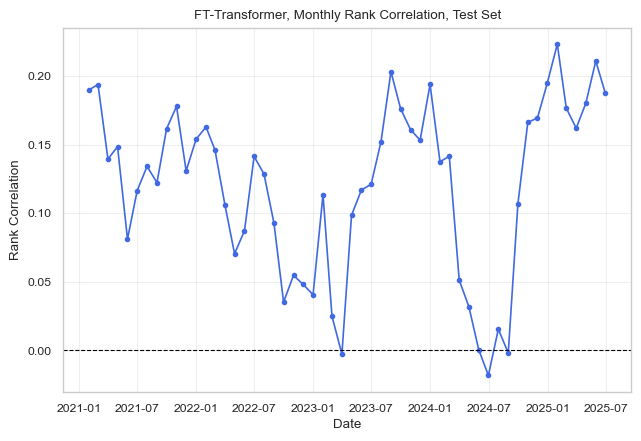

In [21]:
ft_test_pred = pd.read_csv(ft_dir / 'ft_test_predictions.csv')
ft_test_pred['eom'] = pd.to_datetime(ft_test_pred['eom'])

monthly_corr_rows = []
for eom, group in ft_test_pred.groupby('eom'):
	valid = group['prediction'].notna() & group['realised_return'].notna()
	if valid.sum() < 10:
		continue
	c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method='spearman')
	monthly_corr_rows.append({'eom': eom, 'rank_corr': c})
ft_monthly_corr = pd.DataFrame(monthly_corr_rows).sort_values('eom')

# monthly rank correlation, test set
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(ft_monthly_corr['eom'].to_numpy(), ft_monthly_corr['rank_corr'].to_numpy(), color=ft_color, marker='o', markersize=3)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rank Correlation')
ax.set_title('FT-Transformer, Monthly Rank Correlation, Test Set')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_prediction_monthly_corr.png')
plt.show()
plt.close(fig)


#### Validation Diagnostics

In [22]:
with open(ft_dir / 'ft_summary.json') as fh:
	ft_summary_full = json.load(fh)

with open(ft_dir / 'ft_splits.json') as fh:
	ft_splits = json.load(fh)

with open(ft_dir / 'ft_feature_cols.json') as fh:
	ft_feature_cols_info = json.load(fh)

ft_val_pred = pd.read_csv(ft_dir / 'ft_val_predictions.csv')
ft_val_pred['eom'] = pd.to_datetime(ft_val_pred['eom'])

ft_arch = ft_summary_full['architecture']
ft_config = ft_summary_full['config']

print('ft-transformer, architecture summary')
print(f'reference, {ft_arch["reference"]}')
print(f'n_heads, {ft_arch["n_heads"]}, d_model, {ft_arch["d_model"]}, d_ff, {ft_arch["d_ff"]}, n_layers, {ft_arch["n_layers"]}, dropout, {ft_arch["dropout"]}')
print(f'parameter count, {ft_arch["parameter_count"]:,}')
print(f'n_features, {ft_feature_cols_info["n_features"]}')
print()
print('ft-transformer, split summary')
print(f'train, {ft_splits["train_start"]} to {ft_splits["train_end"]}, {ft_splits["n_train_months"]} months')
print(f'val, {ft_splits["val_start"]} to {ft_splits["val_end"]}, {ft_splits["n_val_months"]} months')
print(f'test, {ft_splits["test_start"]} to {ft_splits["test_end"]}, {ft_splits["n_test_months"]} months')
print()
print('ft-transformer, portfolio configuration')
print(f'target vol, {ft_config["target_vol"]}, vol lookback months, {ft_config["vol_lookback_months"]}, max position weight, {ft_config["max_position_weight"]}')
print(f'max leverage long only, {ft_config["max_leverage_long_only"]}, max leverage long short, {ft_config["max_leverage_long_short"]}, tc bps, {ft_config["tc_bps"]}')
print()
print(f'final training time seconds, {ft_train_log["training_time_seconds"]:.1f}, parameter count (train log), {ft_train_log["parameter_count"]:,}')
print(f'best val rank corr, {ft_train_log["best_val_rc"]:.4f}, rc_val, {ft_summary_full["ft_transformer"]["rc_val"]:.4f}, rc_test, {ft_summary_full["ft_transformer"]["rc_test"]:.4f}')

ft-transformer, architecture summary
reference, Gorishniy et al. (2021)
n_heads, 4, d_model, 32, d_ff, 128, n_layers, 3, dropout, 0.17625915357156158
parameter count, 70,305
n_features, 304

ft-transformer, split summary
train, 1995-01-31 to 2015-12-31, 252 months
val, 2016-01-31 to 2020-12-31, 60 months
test, 2021-01-31 to 2025-12-31, 60 months

ft-transformer, portfolio configuration
target vol, 0.1, vol lookback months, 36, max position weight, 0.05
max leverage long only, 3.0, max leverage long short, 3.0, tc bps, 25

final training time seconds, 549.1, parameter count (train log), 70,305
best val rank corr, 0.1114, rc_val, 0.1114, rc_test, 0.1206


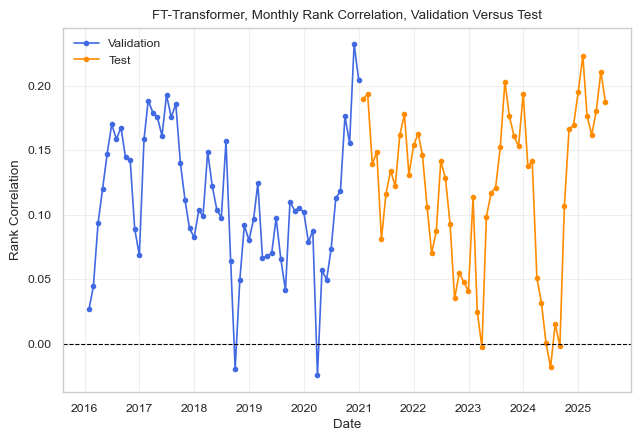

In [23]:
val_monthly_corr_rows = []
for eom, group in ft_val_pred.groupby('eom'):
	valid = group['prediction'].notna() & group['realised_return'].notna()
	if valid.sum() < 10:
		continue
	c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method='spearman')
	val_monthly_corr_rows.append({'eom': eom, 'rank_corr': c})
ft_val_monthly_corr = pd.DataFrame(val_monthly_corr_rows).sort_values('eom')

# monthly rank correlation, validation versus test
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(ft_val_monthly_corr['eom'].to_numpy(), ft_val_monthly_corr['rank_corr'].to_numpy(), color=ft_color, marker='o', markersize=3, label='Validation')
ax.plot(ft_monthly_corr['eom'].to_numpy(), ft_monthly_corr['rank_corr'].to_numpy(), color='darkorange', marker='o', markersize=3, label='Test')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rank Correlation')
ax.set_title('FT-Transformer, Monthly Rank Correlation, Validation Versus Test')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_validation_monthly_corr.png')
plt.show()
plt.close(fig)


---
## Dual Path Portfolio Transformer

#### Hyperparameter

In [24]:
dppt_hpt_dir = Path('results/transformer/transformer-hpt')
dppt_eval_dir = Path('results/transformer')
dppt_eval_plots_dir = Path('plots') / dppt_eval_dir.name
dppt_eval_plots_dir.mkdir(parents=True, exist_ok=True)
dppt_variant_order = ['linear', 'per_feature', 'ple', 'periodic', 'fourier']
dppt_color_map = {v: f'C{k}' for k, v in enumerate(dppt_variant_order)}

trans1 = 'royalblue'

dppt_best_params = {}
for variant in dppt_variant_order:
	params_path = dppt_hpt_dir / f'best_params_{variant}.json'
	if params_path.exists():
		with open(params_path) as fh:
			dppt_best_params[variant] = json.load(fh)

dppt_variants_hpt = [v for v in dppt_variant_order if v in dppt_best_params]

summary_rows = []
for variant in dppt_variants_hpt:
	p = dppt_best_params[variant]
	summary_rows.append({
		'variant': variant,
		'trial_number': p.get('trial_number'),
		'd_model': p.get('d_model'),
		'n_heads': p.get('n_heads'),
		'n_layers': p.get('n_layers'),
		'lr': round(p.get('lr', float('nan')), 6),
		'best_epoch': p.get('best_epoch'),
		'n_epochs_trained': p.get('n_epochs_trained'),
		'val_sharpe_ls': round(p.get('best_val_sharpe_ls', float('nan')), 4),
		'corr_6m': round(p.get('best_corr_6m', float('nan')), 4),
		'base_corr_6m': round(p.get('best_base_corr_6m', float('nan')), 4),
	})
dppt_hpt_summary = pd.DataFrame(summary_rows)
print('dual path portfolio transformer, hyperparameter search summary')
print(dppt_hpt_summary.to_string(index=False))


dual path portfolio transformer, hyperparameter search summary
    variant  trial_number  d_model n_heads n_layers       lr  best_epoch  n_epochs_trained  val_sharpe_ls  corr_6m  base_corr_6m
     linear            15       96    None     None 0.000393           6                14         2.6657   0.1397        0.1378
per_feature            36       64    None     None 0.000078           6                14         2.5179   0.1306        0.0870
        ple             8       64    None     None 0.001133          13                21         2.4915   0.1088        0.1037
   periodic            50       64    None     None 0.000078           6                14         2.3699   0.1399        0.0973
    fourier            23      128    None     None 0.000789          17                25         2.4380   0.1212        0.0759


### Portfolio Evaluation

In [25]:
import re as re_dppt

dppt_metrics = {}
seed_pattern_dppt = re_dppt.compile(r'^metrics_(?P<variant>.+)_seed\d+\.json$')
for metrics_path in sorted(dppt_eval_dir.glob('metrics_*.json')):
	if seed_pattern_dppt.match(metrics_path.name):
		continue
	variant = metrics_path.stem[len('metrics_'):]
	with open(metrics_path) as fh:
		dppt_metrics[variant] = json.load(fh)

dppt_variants_eval = [v for v in dppt_variant_order if v in dppt_metrics]

if len(dppt_variants_eval) == 0:
	raise RuntimeError(
		'no metrics_{variant}.json files found under ' + str(dppt_eval_dir) +
		', run eval_dual_path.py first, this notebook has nothing to plot yet'
	)

comparison_rows = []
monthly_rows = []
for variant in dppt_variants_eval:
	m = dppt_metrics[variant]
	pm = m['portfolio_metrics']
	comparison_rows.append({
		'variant': variant,
		'n_seeds': m.get('ensemble_seed_count'),
		'val_corr': round(m['ensemble_val_rank_corr_6m'], 4),
		'val_sharpe_ls': round(m['validation_portfolio_metrics']['long_short']['sharpe_ratio'], 4),
		'test_corr_6m': round(m['ensemble_test_rank_corr_6m'], 4),
		'sharpe_lo': round(pm['long_only']['sharpe_ratio'], 4),
		'sharpe_lo_u': round(pm['long_only_unscaled']['sharpe_ratio'], 4),
		'sharpe_ls': round(pm['long_short']['sharpe_ratio'], 4),
		'sharpe_ls_u': round(pm['long_short_unscaled']['sharpe_ratio'], 4),
		'vol_ls': round(pm['long_short']['annualised_vol'], 4),
		'vol_ls_u': round(pm['long_short_unscaled']['annualised_vol'], 4),
	})
	monthly_rows.append({
		'variant': variant,
		'sharpe_lo_monthly': round(pm['long_only_monthly']['sharpe_ratio'], 4),
		'sharpe_lo_monthly_u': round(pm['long_only_monthly_unscaled']['sharpe_ratio'], 4),
		'sharpe_ls_monthly': round(pm['long_short_monthly']['sharpe_ratio'], 4),
		'sharpe_ls_monthly_u': round(pm['long_short_monthly_unscaled']['sharpe_ratio'], 4),
	})

dppt_comparison = pd.DataFrame(comparison_rows)
dppt_monthly_comparison = pd.DataFrame(monthly_rows)

dppt_best_variant = max(dppt_variants_eval, key=lambda v: dppt_metrics[v]['ensemble_val_rank_corr_6m'])
dppt_best_sharpe_variant = max(
	dppt_variants_eval,
	key=lambda v: dppt_metrics[v]['validation_portfolio_metrics']['long_short']['sharpe_ratio'],
)

print('dual path portfolio transformer, variant comparison')
print('test set columns are reported, validation set columns are the selection criteria')
print(dppt_comparison.to_string(index=False))
print()
print('monthly frequency sharpe ratios, 6m rebalance, target_1m monthly returns')
print(dppt_monthly_comparison.to_string(index=False))
print()
print(f'best variant by validation rank correlation, {dppt_best_variant}')
print(f'best variant by validation long short sharpe, {dppt_best_sharpe_variant}')

dual path portfolio transformer, variant comparison
test set columns are reported, validation set columns are the selection criteria
    variant  n_seeds  val_corr  val_sharpe_ls  test_corr_6m  sharpe_lo  sharpe_lo_u  sharpe_ls  sharpe_ls_u  vol_ls  vol_ls_u
     linear        5    0.1299         1.3075        0.1059     1.6068       1.4275     1.5800       1.5789  0.1468    0.4406
per_feature        5    0.1289         1.9155        0.1099     2.2900       1.9495     2.2822       2.0902  0.0938    0.2810
        ple        5    0.1070         1.4526        0.0993     0.9338       1.1542     1.0330       1.7408  0.3016    0.3790
   periodic        5    0.1376         1.9674        0.1011     1.7385       1.5556     2.0360       2.0676  0.1256    0.3295
    fourier        5    0.1220         2.8758        0.1131     2.0071       1.7904     2.4404       2.3376  0.1081    0.2984

monthly frequency sharpe ratios, 6m rebalance, target_1m monthly returns
    variant  sharpe_lo_monthly  sharp

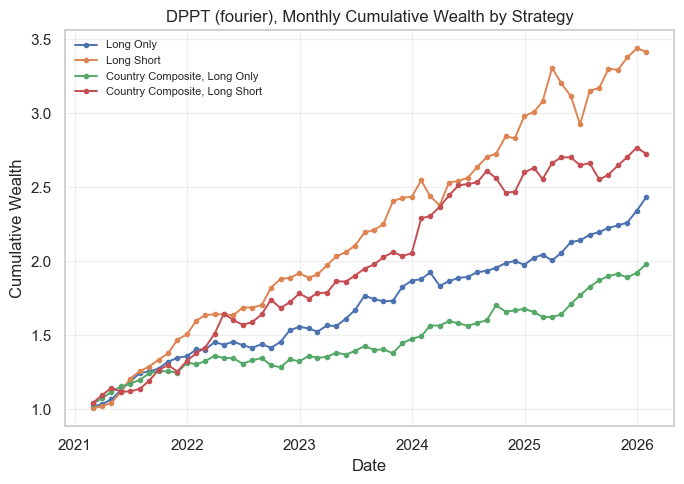

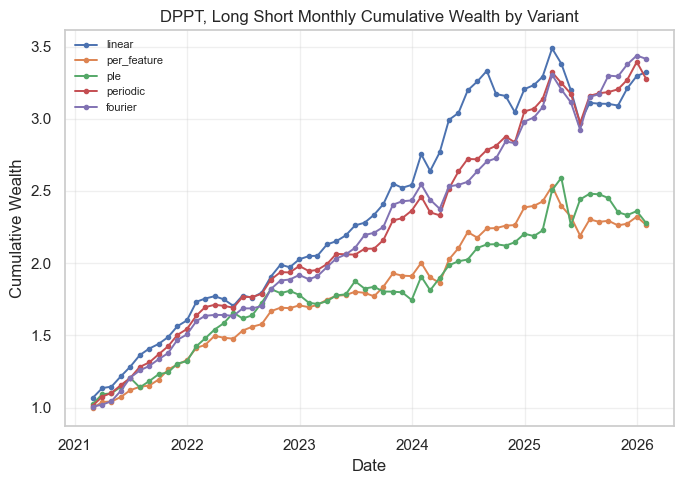

In [26]:
sns.set_theme(style="whitegrid")

marker_style = {'marker': 'o', 'markersize': 3}

dppt_per_month = pd.read_csv(dppt_eval_dir / f'per_month_{dppt_best_sharpe_variant}.csv')
dppt_per_month['eom'] = pd.to_datetime(dppt_per_month['eom'])

dppt_strategy_order = [
	'long_only', 'long_short',
	'country_composite_long_only', 'country_composite_long_short',
]
dppt_strategy_labels = {
	'long_only': 'Long Only',
	'long_short': 'Long Short',
	'country_composite_long_only': 'Country Composite, Long Only',
	'country_composite_long_short': 'Country Composite, Long Short',
}

# monthly cumulative wealth by strategy
fig, ax = plt.subplots(figsize=(7, 5))
for k, strategy in enumerate(dppt_strategy_order):
	sub = dppt_per_month[
		(dppt_per_month['strategy'] == strategy) &
		(dppt_per_month['scaling'] == 'scaled')
	].sort_values('eom')
	if len(sub) == 0:
		continue
	ax.plot(sub['eom'].to_numpy(), sub['cumulative_wealth'].to_numpy(), color=f'C{k}', linewidth=1.4, label=dppt_strategy_labels[strategy], **marker_style)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title(f'DPPT ({dppt_best_sharpe_variant}), Monthly Cumulative Wealth by Strategy')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_sharpe_variant}_cumulative_wealth_by_strategy.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# long short monthly cumulative wealth by variant
fig, ax = plt.subplots(figsize=(7, 5))
for variant in dppt_variants_eval:
	pm_path = dppt_eval_dir / f'per_month_{variant}.csv'
	if not pm_path.exists():
		continue
	pm_v = pd.read_csv(pm_path)
	sub_v = pm_v[(pm_v['strategy'] == 'long_short') & (pm_v['scaling'] == 'scaled')].sort_values('eom')
	if len(sub_v) == 0:
		continue
	ax.plot(pd.to_datetime(sub_v['eom']).to_numpy(), sub_v['cumulative_wealth'].to_numpy(), color=dppt_color_map[variant], linewidth=1.4, label=variant, **marker_style)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('DPPT, Long Short Monthly Cumulative Wealth by Variant')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_sharpe_variant}_cumulative_wealth_by_variant.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

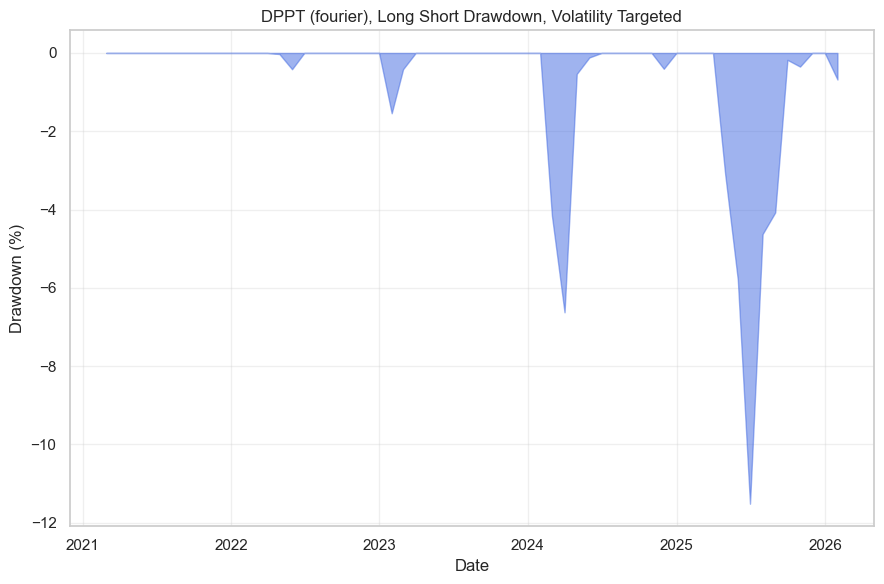

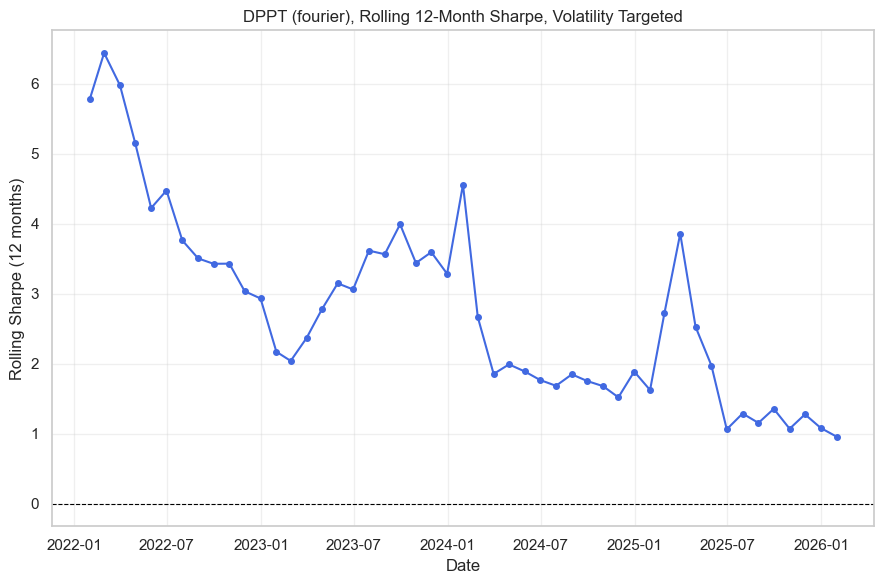

In [27]:
dppt_ls_mo = dppt_per_month[
	(dppt_per_month['strategy'] == 'long_short') &
	(dppt_per_month['scaling'] == 'scaled')
].sort_values('eom')

# long short drawdown, volatility targeted
fig, ax = plt.subplots(figsize=(9, 6))
ax.fill_between(dppt_ls_mo['eom'].to_numpy(), dppt_ls_mo['drawdown'].to_numpy() * 100, alpha=0.5, color=trans1)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title(f'DPPT ({dppt_best_sharpe_variant}), Long Short Drawdown, Volatility Targeted')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_sharpe_variant}_drawdown.png')
plt.show()
plt.close(fig)

# rolling 12-month sharpe, volatility targeted
fig, ax = plt.subplots(figsize=(9, 6))
valid_s = dppt_ls_mo['rolling_sharpe_12m'].notna()
ax.plot(dppt_ls_mo.loc[valid_s, 'eom'].to_numpy(), dppt_ls_mo.loc[valid_s, 'rolling_sharpe_12m'].to_numpy(), color=trans1, marker='o', markersize=4)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title(f'DPPT ({dppt_best_sharpe_variant}), Rolling 12-Month Sharpe, Volatility Targeted')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_sharpe_variant}_rolling_sharpe.png')
plt.show()
plt.close(fig)

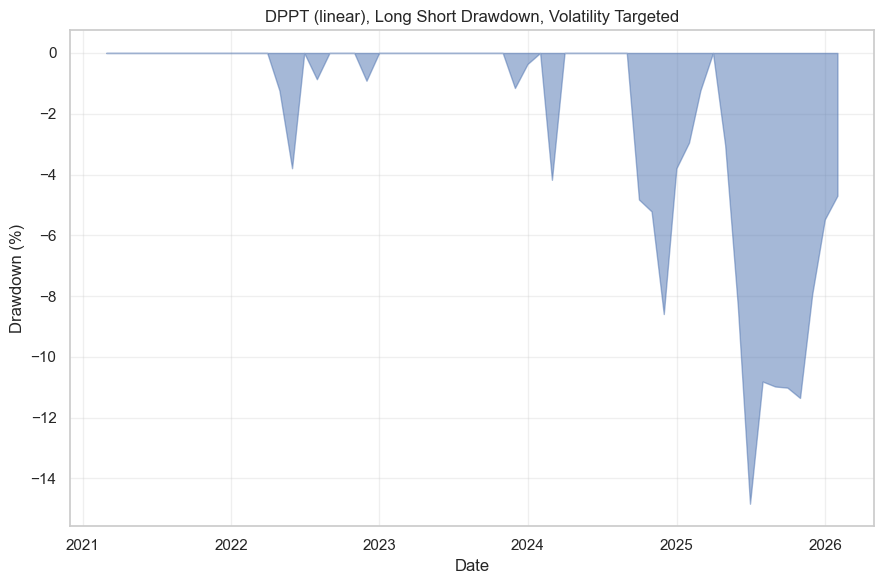

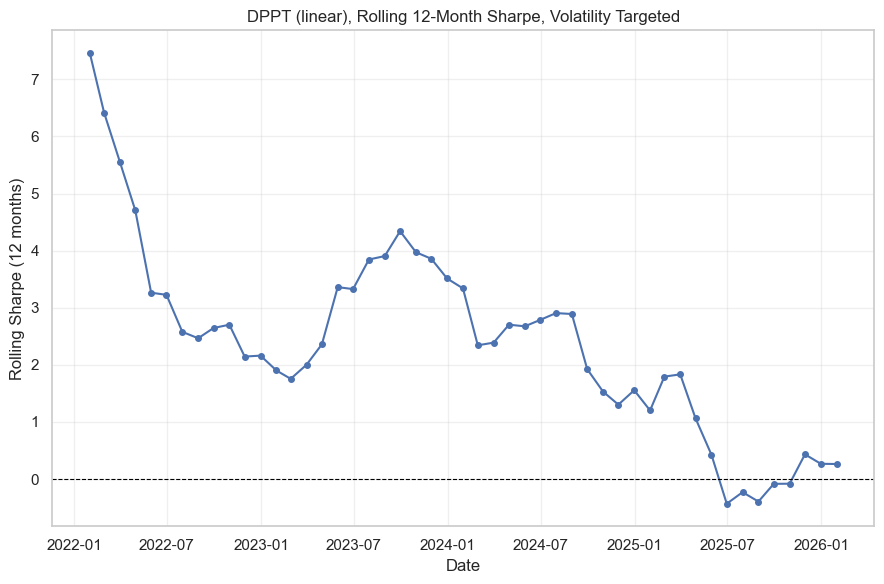

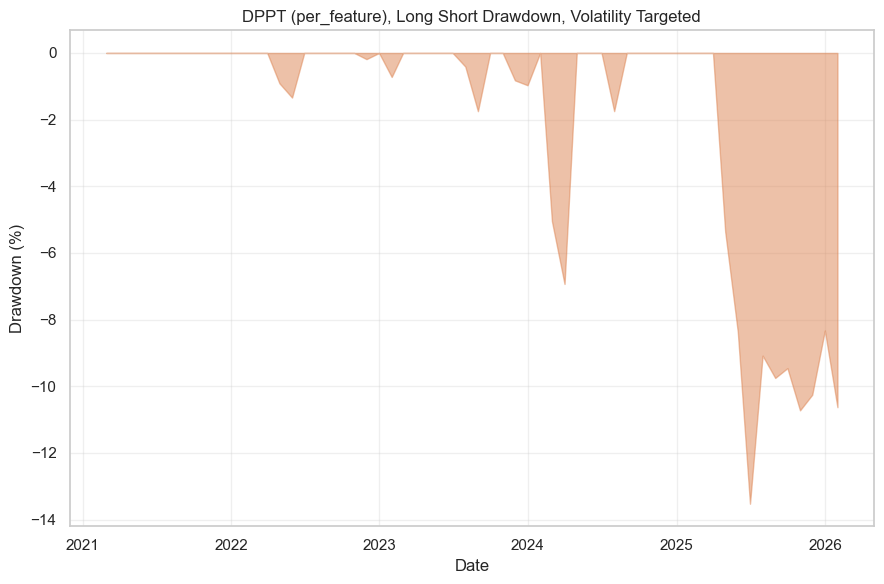

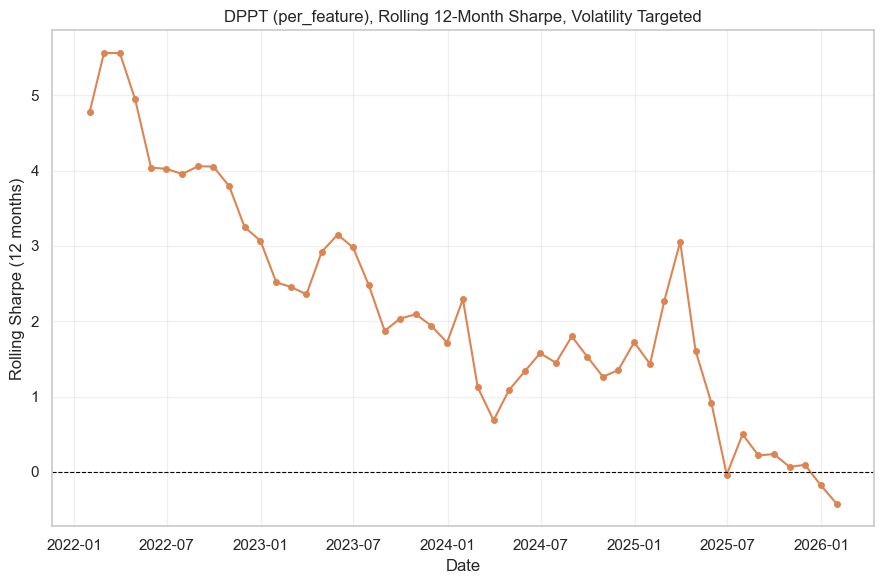

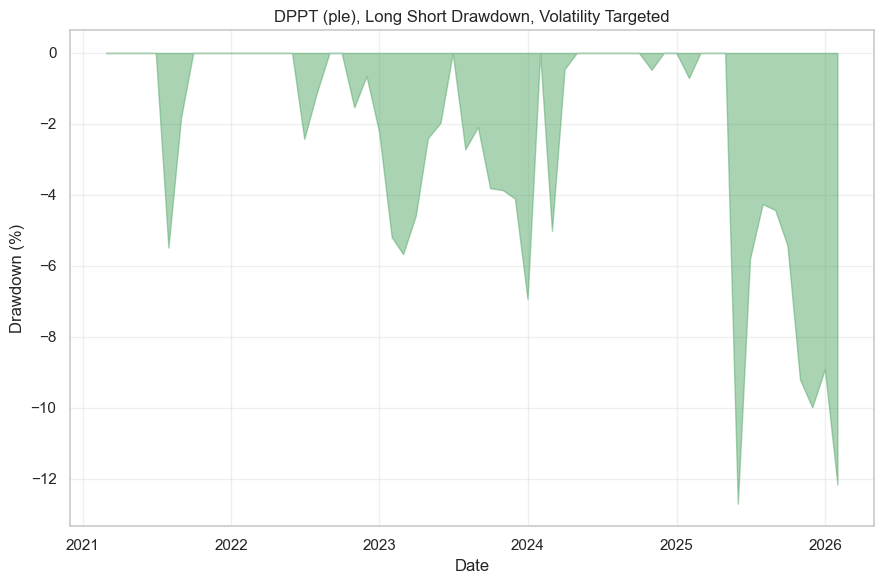

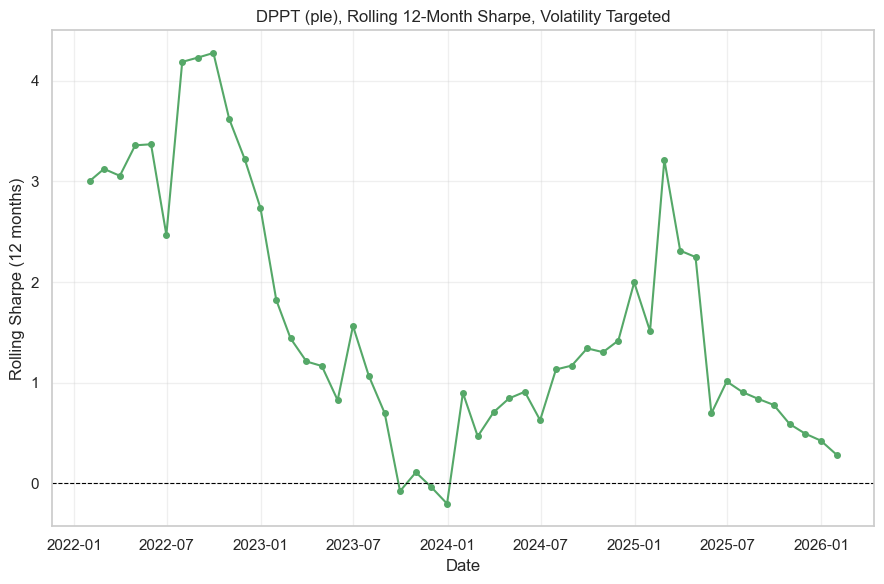

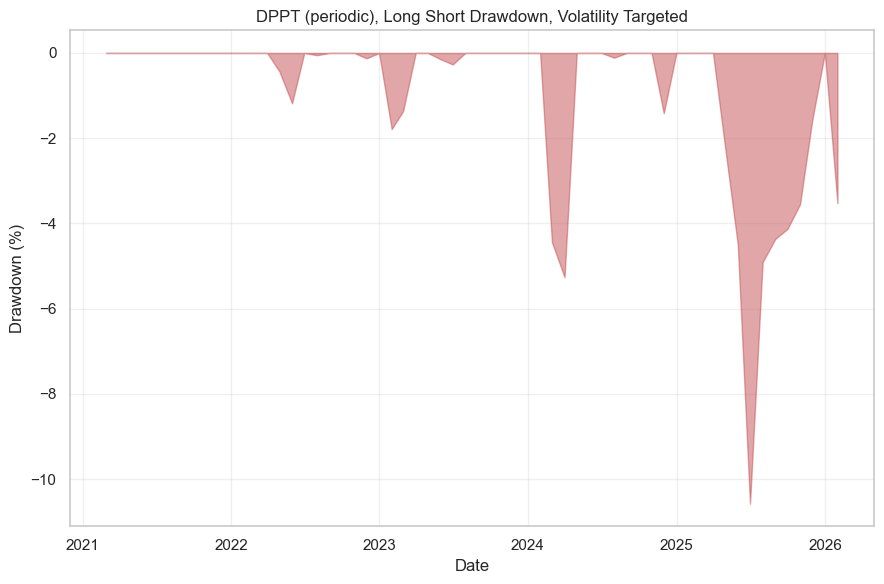

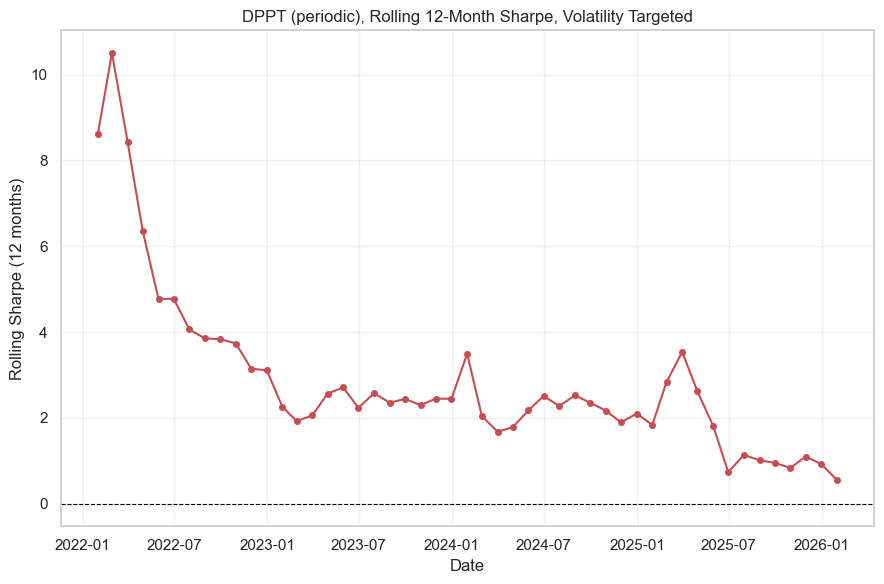

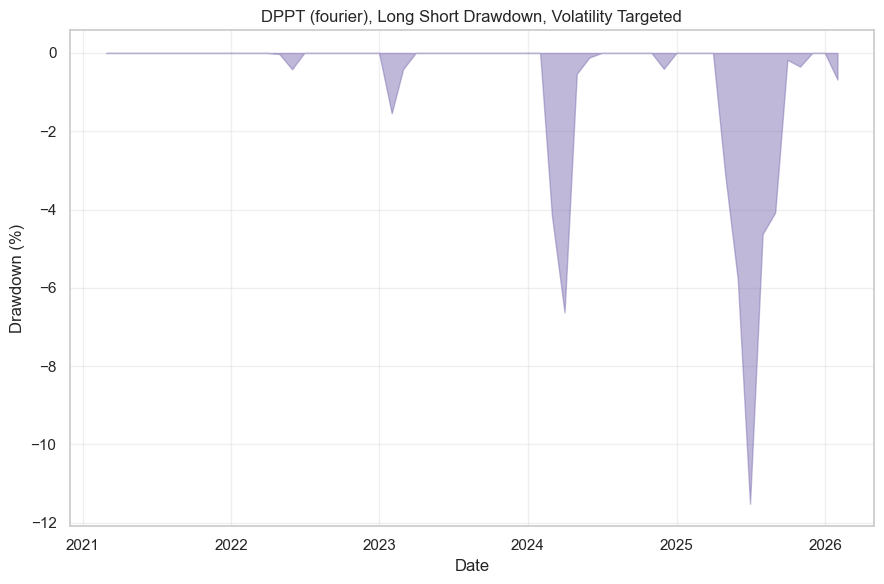

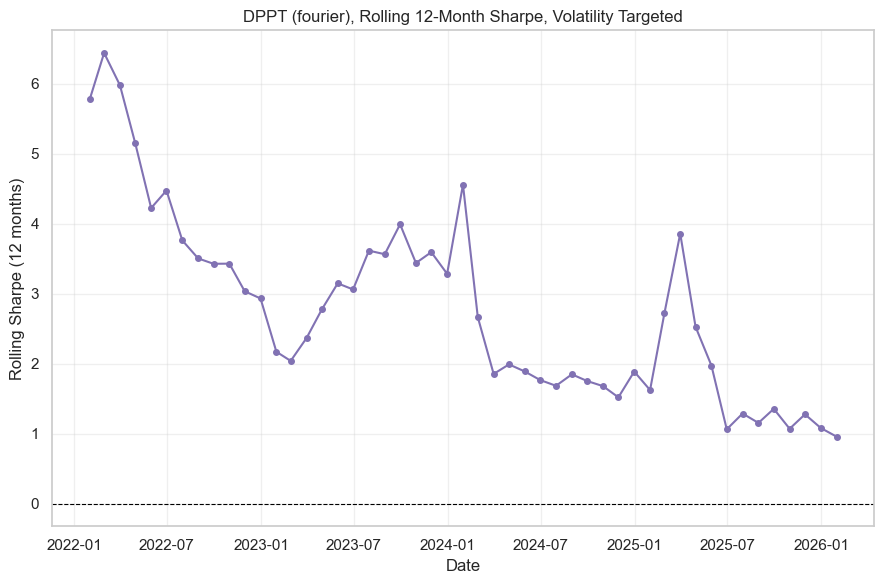

In [28]:
for variant in dppt_variants_eval:
	pm_path = dppt_eval_dir / f'per_month_{variant}.csv'
	if not pm_path.exists():
		continue
	pm_v = pd.read_csv(pm_path)
	pm_v['eom'] = pd.to_datetime(pm_v['eom'])

	ls_mo = pm_v[
		(pm_v['strategy'] == 'long_short') &
		(pm_v['scaling'] == 'scaled')
	].sort_values('eom')
	if len(ls_mo) == 0:
		continue

	color = dppt_color_map[variant]

	# drawdown
	fig, ax = plt.subplots(figsize=(9, 6))
	ax.fill_between(ls_mo['eom'].to_numpy(), ls_mo['drawdown'].to_numpy() * 100, alpha=0.5, color=color)
	ax.set_xlabel('Date')
	ax.set_ylabel('Drawdown (%)')
	ax.set_title(f'DPPT ({variant}), Long Short Drawdown, Volatility Targeted')
	ax.grid(alpha=0.3)
	fig.tight_layout()
	fig.savefig(dppt_eval_plots_dir / f'dppt_{variant}_drawdown.png')
	plt.show()
	plt.close(fig)

	# rolling sharpe
	fig, ax = plt.subplots(figsize=(9, 6))
	valid_s = ls_mo['rolling_sharpe_12m'].notna()
	ax.plot(ls_mo.loc[valid_s, 'eom'].to_numpy(), ls_mo.loc[valid_s, 'rolling_sharpe_12m'].to_numpy(), color=color, marker='o', markersize=4)
	ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
	ax.set_xlabel('Date')
	ax.set_ylabel('Rolling Sharpe (12 months)')
	ax.set_title(f'DPPT ({variant}), Rolling 12-Month Sharpe, Volatility Targeted')
	ax.grid(alpha=0.3)
	fig.tight_layout()
	fig.savefig(dppt_eval_plots_dir / f'dppt_{variant}_rolling_sharpe.png')
	plt.show()
	plt.close(fig)

In [29]:
dppt_per_country_ls = dppt_metrics[dppt_best_sharpe_variant]['per_country']['country_composite_long_short']

country_rows = []
for country_code, entry in dppt_per_country_ls.items():
	country_rows.append({
		'country': country_code,
		'sharpe_ratio': entry['sharpe_ratio'],
		'cumulative_contribution (%)': entry['cumulative_contribution'] * 100,
		'annualised_vol': entry['annualised_vol'],
	})

dppt_country_df = (pd.DataFrame(country_rows).sort_values('sharpe_ratio', ascending=False).reset_index(drop=True))
print("\nCountry Performance (sorted by Sharpe Ratio)\n")
print(dppt_country_df.to_string(index=False))
print("\nCountry Performance (sorted by Cumulative Contribution)\n")
print(dppt_country_df.sort_values('cumulative_contribution (%)', ascending=False).reset_index(drop=True).to_string(index=False))


Country Performance (sorted by Sharpe Ratio)

country  sharpe_ratio  cumulative_contribution (%)  annualised_vol
    BRA      2.129492                     4.682669        0.198563
    PER      2.107753                     0.528619        0.152970
    THA      2.061064                     3.850288        0.174516
    MYS      2.020979                     2.871163        0.180031
    KOR      1.940997                    16.203227        0.225557
    IND      1.860180                    57.860485        0.349876
    TUR      1.810430                     1.708909        0.168669
    HUN      1.744598                     0.145514        0.146005
    SAU      1.715072                    13.105074        0.133323
    PHL      1.602162                     1.478614        0.194970
    CHL      1.576267                     0.654429        0.142137
    EGY      1.444243                     0.255016        0.231363
    POL      1.263773                     1.339754        0.303653
    IDN      1.